# 00. Fundamentos Pytorch

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(torch.__version__)

2.12.0+cu130


## Introdução a tensores



### Criando tensores

In [2]:
#escalar
escalar = torch.tensor(7)
escalar


tensor(7)

In [3]:
escalar.ndim

0

In [4]:
escalar.item()

7

In [5]:
vetor = torch.tensor([7,7])
vetor

tensor([7, 7])

In [6]:
vetor.ndim

1

In [7]:
vetor.shape

torch.Size([2])

In [8]:
matriz = torch.tensor([[7,8],
                       [9,10]])
matriz

tensor([[ 7,  8],
        [ 9, 10]])

In [9]:
matriz.ndim

2

In [10]:
matriz[1][1]

tensor(10)

In [11]:
matriz.shape

torch.Size([2, 2])

In [12]:
tensor = torch.tensor([[[1,2,3],
                        [3,69,100],
                        [4,1209,91]]])
tensor

tensor([[[   1,    2,    3],
         [   3,   69,  100],
         [   4, 1209,   91]]])

In [13]:
tensor.ndim

3

In [14]:
tensor.shape

torch.Size([1, 3, 3])

In [15]:
tensor[0]


tensor([[   1,    2,    3],
        [   3,   69,  100],
        [   4, 1209,   91]])

### Tensores aleatorios

`fluxo = começar com numeros aleatorios -> olhar os dados -> atualizar os numeros aleatorios-> olhar os dados->atualizar os numeros aleatorios`

In [16]:
aleatorio = torch.rand(3,4)
aleatorio

tensor([[0.9422, 0.0524, 0.4855, 0.4172],
        [0.0576, 0.3748, 0.7030, 0.0598],
        [0.9050, 0.6546, 0.1890, 0.7742]])

In [17]:
aleatorio.ndim

2

In [18]:
random_image_size_tensor = torch.rand(size = (224,224,3))#altura,largura,numero de canais
random_image_size_tensor.shape, random_image_size_tensor.ndim

(torch.Size([224, 224, 3]), 3)

In [19]:
zero = torch.zeros(size = (3,4))
zero

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [20]:
zero * aleatorio

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [21]:
one = torch.ones(size = (3,4))

In [22]:
one.dtype

torch.float32

In [23]:
aleatorio.dtype

torch.float32

### Criando tensores com range e tensors-like


In [24]:
um_a_dez = torch.arange(start = 1,end = 11, step = 2)
um_a_dez

tensor([1, 3, 5, 7, 9])

In [25]:
dez_zeros = torch.zeros_like(input = um_a_dez)
dez_zeros

tensor([0, 0, 0, 0, 0])

### Tensors datatypes

**Nota:** tipos de dados de tensores é um dos 3 grandes erros que vou encontrar dentro do pytorch e deep learning:
1. Tensores com tipo de dados errado
2. Tensores com o formato(shape) errado
3. Tensores no "device" errado

In [26]:
float_32_tensor = torch.tensor([3.0,6.0,9.0], 
                               dtype = None, #tipo de dados ex:torch.float32
                               device = None, #qual device esta o seu tensor (cpu, cuda)
                               requires_grad = False)#rastrear ou não os gradientes com essas operações de tensores


float_32_tensor

tensor([3., 6., 9.])

In [27]:
float_32_tensor.dtype

torch.float32

In [28]:
float_16_tensor = float_32_tensor.type(torch.float16)
float_16_tensor

tensor([3., 6., 9.], dtype=torch.float16)

In [29]:
float_32_tensor * float_16_tensor

tensor([ 9., 36., 81.])

In [30]:
int_32_tensor = torch.tensor([3,6,8], dtype = torch.int32)
int_32_tensor

tensor([3, 6, 8], dtype=torch.int32)

In [31]:
int_32_tensor * float_16_tensor

tensor([ 9., 36., 72.], dtype=torch.float16)

### Obtendo informações dos tensores(atributos dos tensores)

1. Tensores com tipo de dados errado - para obter o dtype de um tensor, podemos usar `tensor.dtype`
2. Tensores com o formato(shape) errado - para obter a forma de um tensor, podemos usar `tensor.shape` 
3. Tensores no "device" errado - para obter o dispositivo de um tensor, podemos usar  `tensor.device`

In [32]:
some_tensor = torch.rand(3,4, dtype = torch.float16)
some_tensor

tensor([[0.8643, 0.7100, 0.1552, 0.2491],
        [0.8091, 0.6680, 0.5674, 0.4072],
        [0.5117, 0.9678, 0.7773, 0.9648]], dtype=torch.float16)

In [33]:
print(some_tensor)
print(f"Tipo de dados do tensor: {some_tensor.dtype}")
print(f"Formato do tensor: {some_tensor.shape}")
print(f"Dispositivo do tensor está em: {some_tensor.device}")

tensor([[0.8643, 0.7100, 0.1552, 0.2491],
        [0.8091, 0.6680, 0.5674, 0.4072],
        [0.5117, 0.9678, 0.7773, 0.9648]], dtype=torch.float16)
Tipo de dados do tensor: torch.float16
Formato do tensor: torch.Size([3, 4])
Dispositivo do tensor está em: cpu


### Manipulando tensores(tensor operations)

Operações de tensores incluem:
* Adição
* Subtração
* Multiplicação(element-wise)
* Divisão
* Multiplicações de matrizes

In [34]:
tensor = torch.tensor([1,2,3])
tensor + 10

tensor([11, 12, 13])

In [35]:
tensor * 10

tensor([10, 20, 30])

In [36]:
tensor

tensor([1, 2, 3])

In [37]:
tensor - 10

tensor([-9, -8, -7])

In [38]:
torch.mul(tensor, 10)

tensor([10, 20, 30])

In [39]:
torch.add(tensor, 10)

tensor([11, 12, 13])

### Multiplicação de matrizes

Duas formas principais de realizar a multiplicação em redes neurais e deep learning :
x
1. Element-wise multiplication
2. Multiplicação de matrizes(dot product)

Aqui estao duas regras que tem que ser satisfeitas para a multiplicação de matrizes:
1. As **dimensões internas** tem que combinar:
* `(3,2) @ (3,2)` não funciona
* `(2,3) @ (3,2)` funciona
* `(3,2) @ (2,3)` funciona

2. O resultado das matriz tem o formato das **dimensões externas**:
* `(2,3) @ (3,2)` -> `(2,2)`
* `(3,2) @ (2,3)` -> `(3,3)`


In [40]:
torch.matmul(torch.rand(2,3), torch.rand(3,2))

tensor([[0.3850, 1.1591],
        [0.3450, 0.4346]])

In [41]:
tensor = torch.tensor([1,2,3])

In [42]:
tensor * tensor

tensor([1, 4, 9])

In [43]:
torch.matmul(tensor, tensor)

tensor(14)

In [44]:
%%time
value = 0
for i in range(len(tensor)):
    value += tensor[i] * tensor[i]

value

CPU times: user 139 μs, sys: 876 μs, total: 1.02 ms
Wall time: 737 μs


tensor(14)

In [45]:
%%time
torch.matmul(tensor,tensor)

CPU times: user 398 μs, sys: 0 ns, total: 398 μs
Wall time: 972 μs


tensor(14)

### Um dos erros mais comuns em deep learning: erro de formato

In [46]:
tensor_A = torch.tensor([[1,2],
                         [3,4],
                         [5,6]])

tensor_B = torch.tensor([[7,10],
                         [8,11],
                         [9,12]])

torch.matmul(tensor_A, tensor_B)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (3x2 and 3x2)

In [ ]:
tensor_A.shape, tensor_B.shape

(torch.Size([3, 2]), torch.Size([3, 2]))

In [ ]:
tensor_B.T # transpondo o tensor_B

tensor([[ 7,  8,  9],
        [10, 11, 12]])

In [ ]:
torch.matmul(tensor_A, tensor_B.T)

tensor([[ 27,  30,  33],
        [ 61,  68,  75],
        [ 95, 106, 117]])

In [ ]:
output = torch.matmul(tensor_A, tensor_B.T)
print(f"Formato da saida: {output.shape}")

Formato da saida: torch.Size([3, 3])


### Agregações(min,max,sum,mean) em tensor

In [ ]:
x = torch.arange(0,100,10)
x, x.dtype

(tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]), torch.int64)

In [ ]:
torch.min(x), x.min()

(tensor(0), tensor(0))

In [ ]:
torch.max(x), x.max()

(tensor(90), tensor(90))

In [ ]:
torch.mean(x.type(torch.float32)), x.type(torch.float32).mean()

(tensor(45.), tensor(45.))

In [ ]:
torch.sum(x), x.sum()

(tensor(450), tensor(450))

### Achando a posição do min e max em um tensor


In [ ]:
x

tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

In [ ]:
x.argmin()

tensor(0)

In [ ]:
x[0]

tensor(0)

In [ ]:
x.argmax()

tensor(9)

In [ ]:
x[9]

tensor(90)

### Reshaping, stacking(empilhamento), squeezing e unsqueezing

* Reshape - reformata um tensor de entrada para um formato definido
* View - retorna uma visualização de um tensor de entrada de uma deerminado formato, mas que mantém a memoria original do tensor
* Stacking - combina multiplos tensores um em cima do outro(vstack) ou lado a lado (hstack)
* Squeeze - remove todas as dimensões únicas de um tensor
* unsqueeze - adiciona uma dimensão unica a um tensor de destino
* Permute - retorna uma visualização da entrada com dimensões permutadas(trocadas) de uma determinada maneira

In [ ]:
import torch
x = torch.arange(1.,10.)
x.dtype, x.shape

(torch.float32, torch.Size([9]))

In [ ]:
# Adiciona dimensão extra
x_reshaped = x.reshape(1,9)
x_reshaped, x_reshaped.shape

(tensor([[1., 2., 3., 4., 5., 6., 7., 8., 9.]]), torch.Size([1, 9]))

In [ ]:
# Mudando a view, em uma view, se voce muda a view, muda tambem o que voce atribuiu a view
z = x.view(9,1)
z , z.shape


(tensor([[1.],
         [2.],
         [3.],
         [4.],
         [5.],
         [6.],
         [7.],
         [8.],
         [9.]]),
 torch.Size([9, 1]))

In [ ]:
z[:, 0] = 5
z, x

(tensor([[5.],
         [5.],
         [5.],
         [5.],
         [5.],
         [5.],
         [5.],
         [5.],
         [5.]]),
 tensor([5., 5., 5., 5., 5., 5., 5., 5., 5.]))

In [ ]:
x_stacked = torch.stack([x,x,x,x], dim = 1)
x_stacked, x_stacked.shape

(tensor([[5., 5., 5., 5.],
         [5., 5., 5., 5.],
         [5., 5., 5., 5.],
         [5., 5., 5., 5.],
         [5., 5., 5., 5.],
         [5., 5., 5., 5.],
         [5., 5., 5., 5.],
         [5., 5., 5., 5.],
         [5., 5., 5., 5.]]),
 torch.Size([9, 4]))

In [ ]:
x_vstack = torch.vstack([x,x,x,x])
x_vstack, x_vstack.shape

(tensor([[5., 5., 5., 5., 5., 5., 5., 5., 5.],
         [5., 5., 5., 5., 5., 5., 5., 5., 5.],
         [5., 5., 5., 5., 5., 5., 5., 5., 5.],
         [5., 5., 5., 5., 5., 5., 5., 5., 5.]]),
 torch.Size([4, 9]))

In [ ]:
x_hstack = torch.hstack([x,x,x,x])
x_hstack, x_hstack.shape

(tensor([5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
         5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.]),
 torch.Size([36]))

In [ ]:
x_reshaped

tensor([[5., 5., 5., 5., 5., 5., 5., 5., 5.]])

In [ ]:
x_reshaped.shape

torch.Size([1, 9])

In [ ]:
x_reshaped.squeeze()

tensor([5., 5., 5., 5., 5., 5., 5., 5., 5.])

In [ ]:
x_reshaped.squeeze().shape

torch.Size([9])

In [ ]:
x_squeeze = x_reshaped.squeeze()
x_unsqueeze = x_squeeze.unsqueeze(dim = 0)

In [ ]:
print(f"Tensor anterior: {x_squeeze}")
print(f"Formato anterior: {x_squeeze.shape}")
print(f"Tensor atual: {x_unsqueeze}")
print(f"Formato atual: {x_unsqueeze.shape}")

Tensor anterior: tensor([5., 5., 5., 5., 5., 5., 5., 5., 5.])
Formato anterior: torch.Size([9])
Tensor atual: tensor([[5., 5., 5., 5., 5., 5., 5., 5., 5.]])
Formato atual: torch.Size([1, 9])


In [ ]:
x_original = torch.rand(size = (224,224,3))

x_permuted = x_original.permute(2,0,1)
x_original.shape, x_permuted.shape 

(torch.Size([224, 224, 3]), torch.Size([3, 224, 224]))

In [ ]:
x_original[0,0,0] = 5

x_original[0,0,0], x_permuted[0,0,0]

(tensor(5.), tensor(5.))

### Selecionando dados de tensores com indexação

Indexação em Pytorch é parecido com indexação em Numpy

In [ ]:
import torch
x = torch.arange(1,10).reshape(1,3,3)
x, x.shape

(tensor([[[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]]),
 torch.Size([1, 3, 3]))

In [ ]:
x[0]

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [ ]:
x[0][0]

tensor([1, 2, 3])

In [ ]:
x[0][0][0]

tensor(1)

In [ ]:
# Usamos : para selecionar todos os valores da dimensao desejada
x[:,0]


tensor([[1, 2, 3]])

In [ ]:
x[:,:,1]

tensor([[2, 5, 8]])

In [ ]:
x[:,1,1]

tensor([5])

In [ ]:
x[0,0,:]

tensor([1, 2, 3])

In [ ]:
x

x[0,2,2]



tensor(9)

In [ ]:
x
x[:, :, 2]

tensor([[3, 6, 9]])

### Tensores Pytorch e numpy

Numpy é uma biblioteca python cientifica popular 

E por isso, Pytorch tem funionalidade para interagir com ela

* Dados em Numpy(np.array) e querer isso em um tensor Pytorch -> `torch.from_numpy(ndarray)`
* Pytorch tensor -> Numpy -> `torch.Tensor.numpy()`

In [ ]:
# Quando convertemos numpy -> pytorch, o tensor reflete o padrao de dados do numpy(float64), a menos que especificada de outra forma
import torch
import numpy as np
array = np.arange(1.0,8.0)
tensor = torch.from_numpy(array)
array, tensor

(array([1., 2., 3., 4., 5., 6., 7.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [ ]:
array.dtype

dtype('float64')

In [ ]:
torch.arange(1.0, 8.0).dtype


torch.float32

In [ ]:
# Se mudar o valor do array numpy, o que acontecera com o tensor pytorch?
array = array + 1
array, tensor

(array([2., 3., 4., 5., 6., 7., 8.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [ ]:
# Tensor para array numpy
tensor = torch.ones(7)
numpy_tensor = tensor.numpy()
tensor, numpy_tensor

(tensor([1., 1., 1., 1., 1., 1., 1.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

In [ ]:
numpy_tensor.dtype

dtype('float32')

In [ ]:
# Mudando o tensor, o que acontece ao "tensor  numpy"?
tensor = tensor + 1
tensor, numpy_tensor

(tensor([2., 2., 2., 2., 2., 2., 2.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

### Reprodutibilidade (tentando eliminar o estado aleatorio(random))

Resumindo, como a rede neural aprende é:
`Começar com números aleatórios -> operações de tensores -> atualizar números aleátorios para torná-los melhores representações dos dados -> de novo -> de novo -> de novo...`

Para reduzir a aleatoriedade em redes neurais e Pytorch, tras o conceito de **random seed**

Essencialmente, o que a seed faz é "suavizar" a aleatoriedade


In [ ]:
import torch
random_tensor_A = torch.rand(3,4)
random_tensor_B = torch.rand(3,4)

print(random_tensor_A)
print(random_tensor_B)
print(random_tensor_A==random_tensor_B)

tensor([[0.3648, 0.1490, 0.8693, 0.0294],
        [0.5449, 0.0794, 0.2313, 0.2927],
        [0.3386, 0.3708, 0.0831, 0.0944]])
tensor([[0.6568, 0.7708, 0.1053, 0.1467],
        [0.1932, 0.9118, 0.1488, 0.0913],
        [0.4470, 0.2440, 0.5571, 0.1928]])
tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False, False, False]])


In [ ]:
# Criando tesnores aleatorios mas reproduziveis
import torch

# Set the random seed
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

random_tensor_C = torch.rand(3,4)

torch.manual_seed(RANDOM_SEED)

random_tensor_D = torch.rand(3,4)

print(random_tensor_C)
print(random_tensor_D)
print(random_tensor_C == random_tensor_D)

tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])


### Executando tensores e objetos Pytorch em GPUs (e fazer calculos mais rapidos)

GPUs = computação mais rapida com números, graças ao CUDA + NVIDIA hardware + Pytorch trabalhando nos bastidores para deixar tudo perfeito

### 1. Obtendo a GPU

1. Fácil - Use o Google Colab para obter uma GPU gratuita(opções de melhora)
2.  Use your own GPU - exige um pouco de configuração e o investimento na compra de uma GPU, tem muitas opções... , veja esse post para ver qual opção adquirir: https://timdettmers.com/2023/01/30/which-gpu-for-deep-learning/
3. Usar computação em nuvem - GCP, AWS, Azure, esses serviços permitem alugar computadores na nuvem e acessá-los

Para 2,3 Pytorch + drivers GPU(CUDA), é necessário um pouco de configuração, para fazer isso, consulte a documentação de configuração do Pytorch



In [ ]:
!nvidia-smi

/bin/bash: linha 1: nvidia-smi: comando não encontrado


### 2. Checando o acesso da GPU pelo Pytorch
 

In [ ]:
# Checando o acesso a GPU com Pytorch
import torch
torch.cuda.is_available()

False

Para o Pytorch, já que ele é capaz de executar computação na GPU ou CPU é uma pratica recomendada configurar um código independente de dispositivo agnóstico: https://pytorch.org/docs/stable/notes/cuda.html#best-pratices

Executar na GPU se disponível, senão o padrão é CPU

In [ ]:
# Configurando o dódigo agnóstico de dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

In [ ]:
# Contar o numero de dispositivos
torch.cuda.device_count()

0

### 3. Colocando tensores(e modelos) na GPU

O motivo pelo qual queremos nossoos tensores/modelos na GPU, é porque o uso da GPU resulta em cálculos mais rápidos 


In [ ]:
tensor = torch.tensor([1,2,3])

print(tensor, tensor.device)

tensor([1, 2, 3]) cpu


In [ ]:
# Mover o tensor para a GPU(se disponível)
tensor_on_gpu = tensor.to(device)
tensor_on_gpu, tensor_on_gpu.device

(tensor([1, 2, 3]), device(type='cpu'))

### 4. Movendo os tensores de volta para a CPU

In [ ]:
# Se o tensor estiver na GPU, nao será possível transformar em Numpy

tensor_on_gpu.numpy()

array([1, 2, 3])

In [ ]:
# Para corrigir o problema do tensor na GPU com numpy, podemos primeiro configurá-lo para a CPU
tensor_back_on_cpu = tensor_on_gpu.cpu().numpy()

tensor_back_on_cpu

array([1, 2, 3])

In [ ]:
tensor_on_gpu

tensor([1, 2, 3])

### Exercícios e extra-curricular

In [ ]:
#Exercício 1
import torch
a = torch.rand(7,7)
a


tensor([[0.1550, 0.7762, 0.7565, 0.8359, 0.2800, 0.6961, 0.3430],
        [0.7640, 0.8203, 0.3122, 0.7982, 0.8636, 0.0893, 0.2483],
        [0.7322, 0.6375, 0.6715, 0.4274, 0.2987, 0.7051, 0.7137],
        [0.7311, 0.2224, 0.5042, 0.0370, 0.3588, 0.0055, 0.8931],
        [0.8306, 0.1997, 0.9146, 0.1969, 0.1751, 0.6494, 0.9065],
        [0.7472, 0.5954, 0.0494, 0.4681, 0.7331, 0.2178, 0.7691],
        [0.9957, 0.1058, 0.1587, 0.2967, 0.9508, 0.3936, 0.5730]])

In [ ]:
b = torch.rand(1,7)
transposto = b.T
print(f"{torch.matmul(a, transposto)}")

tensor([[1.7545],
        [1.4544],
        [1.5182],
        [0.6960],
        [1.2307],
        [1.1970],
        [0.9914]])


In [ ]:
SEED = 42
torch.manual_seed(SEED)
c = torch.rand(7,7)
torch.manual_seed(SEED)
d = torch.rand(1,7)
d_t = d.T
print(f"Multiplicação da primeira matriz: {c}")
print(f"Com a segunda matriz transposta: {d_t}")
print(f"Resultado: {torch.matmul(c,d_t)}")



Multiplicação da primeira matriz: tensor([[0.8823, 0.9150, 0.3829, 0.9593, 0.3904, 0.6009, 0.2566],
        [0.7936, 0.9408, 0.1332, 0.9346, 0.5936, 0.8694, 0.5677],
        [0.7411, 0.4294, 0.8854, 0.5739, 0.2666, 0.6274, 0.2696],
        [0.4414, 0.2969, 0.8317, 0.1053, 0.2695, 0.3588, 0.1994],
        [0.5472, 0.0062, 0.9516, 0.0753, 0.8860, 0.5832, 0.3376],
        [0.8090, 0.5779, 0.9040, 0.5547, 0.3423, 0.6343, 0.3644],
        [0.7104, 0.9464, 0.7890, 0.2814, 0.7886, 0.5895, 0.7539]])
Com a segunda matriz transposta: tensor([[0.8823],
        [0.9150],
        [0.3829],
        [0.9593],
        [0.3904],
        [0.6009],
        [0.2566]])
Resultado: tensor([[3.2618],
        [3.4084],
        [2.4866],
        [1.4525],
        [1.7079],
        [2.7291],
        [2.9204]])


In [ ]:
RANDOM_SEED = 1234
torch.manual_seed(RANDOM_SEED)
tensor1 = torch.rand(2,3)
torch.manual_seed(RANDOM_SEED)
tensor2 = torch.rand(2,3)
tensor_reformatado = tensor2.reshape(3,2)
resultado = torch.matmul(tensor1, tensor_reformatado)
print(f"Multiplicação dos tensores: {resultado}")



Multiplicação dos tensores: tensor([[0.1204, 0.3411],
        [0.0666, 0.6596]])


In [ ]:
v_max = resultado.max()
v_min = resultado.min()
pos_max = resultado.argmax()
pos_min = resultado.argmin()

print(f"Valor máximo: {v_max}")
print(f"Posição máxima: {pos_max}")
print(f"Valor mínimo: {v_min}")
print(f"Posição do valor mínimo: {pos_min}")


Valor máximo: 0.6596311330795288
Posição máxima: 3
Valor mínimo: 0.06662219762802124
Posição do valor mínimo: 2


In [ ]:
torch.manual_seed(7)
random = torch.rand(1,1,1,10)
random2 = random.squeeze()

print(f"Primeiro tensor: {random}")
print(f"Formato do primeiro tensor: {random.shape}")
print(f"Segundo tensor: {random2}")
print(f"Formato do segundo tensor: {random2.shape}")

Primeiro tensor: tensor([[[[0.5349, 0.1988, 0.6592, 0.6569, 0.2328, 0.4251, 0.2071, 0.6297,
           0.3653, 0.8513]]]])
Formato do primeiro tensor: torch.Size([1, 1, 1, 10])
Segundo tensor: tensor([0.5349, 0.1988, 0.6592, 0.6569, 0.2328, 0.4251, 0.2071, 0.6297, 0.3653,
        0.8513])
Formato do segundo tensor: torch.Size([10])


# 01. Pytorch Workflow


In [ ]:
o_que_cobrimos = {1: "data(prepare and load)",
                  2: "criar um modelo",
                  3: "ajustar o modelo aos dados(training)",
                  4: "fazer previsões e avaliar o modelo(inferência)",
                  5: "salvar e carregar um modelo",
                  6: "juntar tudo"}

o_que_cobrimos

{1: 'data(prepare and load)',
 2: 'criar um modelo',
 3: 'ajustar o modelo aos dados(training)',
 4: 'fazer previsões e avaliar o modelo(inferência)',
 5: 'salvar e carregar um modelo',
 6: 'juntar tudo'}

In [ ]:
import torch
from torch import nn # nn contém todos os blocos de construção do Pytorch para redes neurais
import matplotlib.pyplot as plt

# Checar a versão do PyTorch
torch.__version__

'2.12.0+cu130'

## 1. Dados (preparando e carregando)

Dados podem ser praticamente qualquer coisa... em machine learning.

* Tabela Excel
* Imagens de qualquer tipo
* Videos (YouTube tem muitos dados...)
* Audios como músicas ou podcasts
* DNA
* Texto

Machine Learning é um jogo de duas partes:
1. Obter dados em uma representação numérica.
2. criar um modelo para aprender padrões nessa representação numérica.

Para mostrar isso, vamos criar alguns dados *conhecidos* usando a formula da regressão linear.

Usaremos a fomula da regressão linear para fazer uma linha reta com **parâmetros** *conhecidos*

In [ ]:
# Criando parâmetros conhecidos
weight = 0.7
bias = 0.3

# Criando dados
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim = 1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(X), len(y)

(50, 50)

### Separando os dados em conjuntos de treinamento e teste ( um dos mais importantes conceitos em machine learning)

Vamos criar um conjunto de treinamento e teste com nossos dados.

In [ ]:
# Crie uma divisão treino/teste
train_split = int(0.8 * len(X))
X_train , y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Como podemos visualizar melhor nossos dados?

é aí que entra o lema do explorador de dados

"Visualize, visualize, visualize"

In [ ]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):
    """
    Plot dados de treinamento, dados de teste e compare as predições.
    """
    plt.figure(figsize = (10,7))

    # Plotar os dados de treinamento em azul
    plt.scatter(train_data, train_labels, c = "b", s = 4, label = "Dados de treinamento")

    #Plotar os dados de teste em verde
    plt.scatter(test_data, test_labels, c = "g", s = 4, label = "Dados de teste")

    # E as previsões?
    if predictions is not None:
        # Plotar as previsões se elas existirem
        plt.scatter(test_data, predictions, s = 4, c = "r", label = "Previsões")

        # Mostrar a legenda
        plt.legend(prop = {"size": 14});


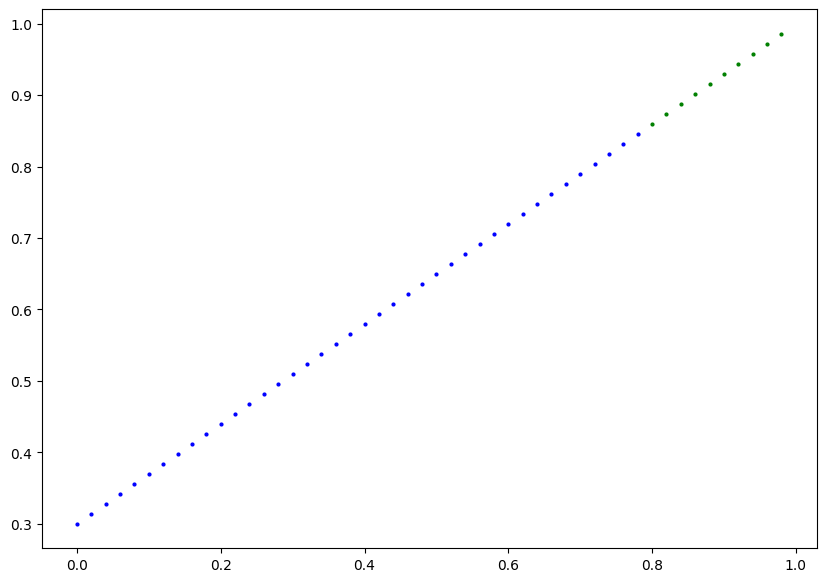

In [ ]:
plot_predictions();

## 2. Construir o modelo

Nosso primiero modelo PyTorch

O que nosso modelo faz:
* Começa com valores aleatórios(weight e bias)
* Olha os dados de treinamento e ajusta os valores aleatórios para representar melhor (ou chegar mais perto) os valores ideais ( o weight e o bias nós usamos para criar os dados)

Como ele faz isso?

Por meio de dois algoritmos principais:
1. Descida do Gradiente
2. Backpropagation

In [34]:
from torch import nn

# Crie uma classe de modelo de regressão linear
class LinearRegressionModel(nn.Module): # <- quase tudo no PyTorch herda de nn.Module
    def __init__(self):
        super().__init__() # Chama o construtor da classe pai, para ja criar os dicionarios weights e bias
        self.weights = nn.Parameter(torch.randn(1, # <- começa com um numero aleatorio do peso e tenta ajustar para o peso ideal
                                                requires_grad = True, # <- esse parametro pode ser atualizado pela descida do gradiente?
                                                dtype = torch.float)) # <- PyTorch ama o datatype toch.float32
        print(self.weights)
    
        self.bias = nn.Parameter(torch.randn(1, # <- começa com um bias aleatorio e tenta ajustar ele ao bias ideal
                                            requires_grad = True, # <- esse parametro pode ser atualizado pela descida do gradiente?
                                            dtype = torch.float)) # <- PyTorch ama o datatype toch.float32
        
        # Método Forward para definir o cálculo no modelo
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" são os dados de entrada, x: torch.Tensor espera que a entrada seja um tensor e -> torch.Tensor espera que a saída seja um Tensor
        return self.weights * x + self.bias # Essa é a fórmula da regressão linear


In [35]:
model_0 = LinearRegressionModel()
model_0.state_dict()

Parameter containing:
tensor([0.4617], requires_grad=True)


OrderedDict([('weights', tensor([0.4617])), ('bias', tensor([0.2674]))])

### Itens essenciais de construção de modelos do PyTorch

* torch.nn - contem todos os blocos de construção de grafos computacionais(uma rede neural pode ser considerada um grafo computacional)
* torch.nn.Parameter - Quais parametros nosso modelo deve tentar e aprender, frequentemente uma camada PyTorch de torch.nn define isso para nós
* torch.nn.Module - A classe base para todos os nossos módulos de rede neural, se voce esta com a subclasse, deve sobrescrever forward()
* torch.optim - é aqui que os otimizaores do PyTorch vivem, eles ajudarão na descida do gradiente
* def forward() - todas as subclasses de nn.Module exigem que voce sobrescreva forward, ese método define o que acontece no cálculo forward

### Checando o conteudo do nosso modelo PyTorch

Agora criamos um modelo, vamos ver o que tem dentro..

Podemos verificar os parametros do nosso modelo ou o que esta dentro dele usando `.parameters() `.

In [ ]:
# Listar os parametros nomeados
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Fazendo previsões usando `torch.inference_mode()`

Para verificar a capacidade de previsão do nosso modelo, vamos ver o quão bem ele prevê `y_test`  com base no `X_test`.

Quando passarmos os dados pelo nosso modelo, ele sera executado pelo método forward

In [ ]:
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [ ]:
# Fazer previsões com o modelo
with torch.inference_mode():
    y_preds = model_0(X_test)


# Pode-se fazer algo semelhante com o torch.no_grad(), mas torch.inference_mode() é preferido
#with torch.no_grad():
    #y_preds = model_0(X_test)


y_preds    


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [ ]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

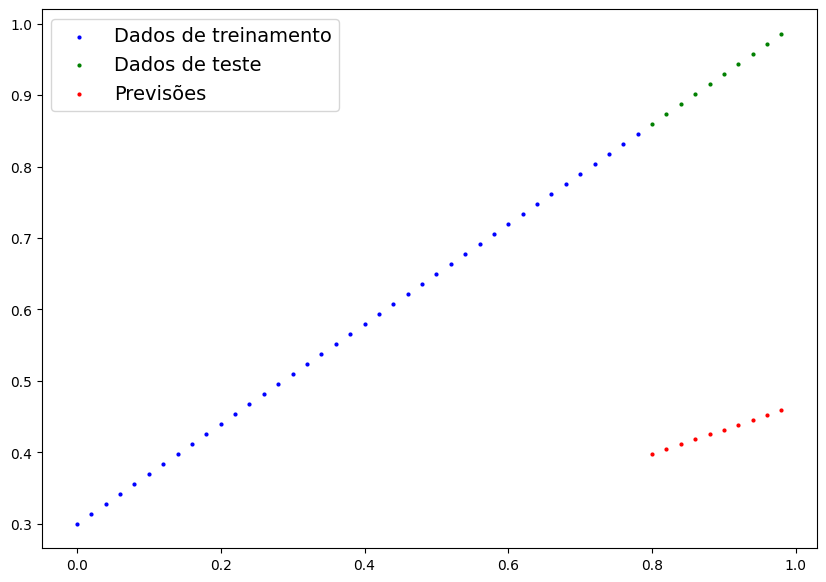

In [ ]:
plot_predictions(predictions = y_preds)

## 3. Treinando o modelo

A ideia geral do treinamento é que um modelo se mova a partir de alguns parâmetros *desconhecidos* (esses podem ser aleatórios) para alguns paramêtros *conhecidos*

Ou em outras palavras de uma pior representação dos dados a uma melhor representação dos dados.

Uma maneira de medir quão ruins ou quão erradas estao as previsões do seu modelo é usar uma função de perda(Loss Function)

* Nota: Funçao de perda pode ser chamada função de custo(cost function) ou criterio em diferentes áreas. Em nosso caso, vamos nos referir a isso como função de perda.

Coisas que precisamos treinar:

* **Loss Function:** é uma função para medir o quanto as previsões de seu modelo estão erradas em relação aos resultados, quanto menor melhor.
* **Optimizador:** Leva em conta a perda de um modelo e ajusta os parâmetros do modelo(pesos e vieses no nosso caso) para melhorar a funçao de perda.
 - Dentro do otimizador temos dois parâmetros:
     - `params`- os parametros do modelo que voce deseja otimizar, por exemplo `params = model_o.parameters()`
     - `lr`(learning rate)- a taxa de aprendizado é um hiperparâmetro que define quão grande/pequeno o otimizador mudar os parâmetros a cada passo( um pequeno lr resulta em uma pequena mudança, um grande lr resulta em uma grande mudança)

E especificamente para o PyTorch, nós precisamos de: 
* Um looping de treinamento
* Um looping de teste


In [ ]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# Checando os parâmetros do nosso modelo( um parÂmetro é um valor que o próprio modelo define)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# Configurar uma função de perda
loss_fn = nn.L1Loss()

# Configurar um otimizador (descida do gradiente estocastica)
optimizer =  torch.optim.SGD(params = model_0.parameters(), lr = 0.01) # lr = possivelmente o hiperparâmetro de aprendizado mais importante que voce pode definir

**P**: Qual função de perda e otimizador devo usar?

**R**: Isso depende do problema. Mas com experiência voce tera uma ideia do que funciona e o que não funciona para o seu problema em particular

Por exemplo, para um problema de regressão linear(como o nosso), a loss function de `nn.L1Loss` e o otimizador `torch.optim.SGD()`são suficientes.

Mas para um problema de classificação, como classificar qual foto é de um cachorro ou gato, voce provavelmente usaria a loss funcion  `nn.BCELoss()` (Entropia cruzada binária ).

### Construindo um loop de treinamento(e loop de teste) em PyTorch

Algumas coisas que fizemos no loop de treinamento:
0. Loop por meio dos dados e faça...
1. Forward pass ( isso envolve a movimentação dos dados em nossas funções `forward()`) para fazer previsões nos dados - também chamado de Forward Propagation
2. Calcular a perda (comparar as previsões forward pass com os verdadeiros rótulos)
3. Otimizador zero grad
4. Loss Backward - mover-se para trás na rede para calcular os gradientes de cada um dos parâmetros do nosso modelo com relação à perda(**backpropagation**)
5. Otimizador - isso usará o otimizador para ajustar os parâmetros de nossos modelos para melhorar a perda(**gradient descent**)

In [ ]:
torch.manual_seed(42)

# Epócas são um loop pelos dados... ( isso é um hiperparâmetro por que nós mesmos definimos)
epochs = 200

epoch_count = []
loss_values = []
test_loss_values = []

### Treinando
# 0. Percorrer os dados em loop
for epoch in range(epochs):
    # coloca o modelo em modo treinamento (ativa Dropout/BatchNorm)
    model_0.train()
    
    #1. Forward pass(Previsão)
    y_pred = model_0(X_train)

    # 2. Calcular a perda de treino
    loss = loss_fn(y_pred, y_train)

    # 3. zerar os gradientes
    optimizer.zero_grad()

    # 4. Executa backpropagation sobre a perda com relação aos parâmetros do modelo
    loss.backward()

    # 5. Otimizador (executa a descida do gradiente)
    optimizer.step() # Por default , essas alterações do otimizador serâo acumuladas através do loop entao temos que zerá-los acima, na etapa 3 para a próxima iteração do loop


    ### Teste
    model_0.eval() # desativa diferetes configurações no modelo que não são necessárias para avaliação/teste (dropout/batch normalization)
    with torch.inference_mode(): #desativa o rastreamento de gradientes e mais algumas coisas nos bastidores
        # with torch.no_grad(): # Voce pode talvez ver torch.no_grad em codigos PyTorch mais antigos
        # 1. fazer o forward pass(previsões)
        test_pred = model_0(X_test)

        #2. Calcular a perda
        test_loss = loss_fn(test_pred, y_test)
    # Printar o que esta acontecendo
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"época: {epoch} | Perda: {loss} | test loss: {test_loss} ")
        print(model_0.state_dict())

época: 0 | Perda: 0.31288138031959534 | test loss: 0.48106518387794495 
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
época: 10 | Perda: 0.1976713240146637 | test loss: 0.3463551998138428 
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
época: 20 | Perda: 0.08908725529909134 | test loss: 0.21729660034179688 
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
época: 30 | Perda: 0.053148526698350906 | test loss: 0.14464017748832703 
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
época: 40 | Perda: 0.04543796554207802 | test loss: 0.11360953003168106 
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
época: 50 | Perda: 0.04167863354086876 | test loss: 0.09919948130846024 
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
época: 60 | Perda: 0.03818932920694351 | test loss: 0.08886633068323135 
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
época: 7

In [ ]:
import numpy as np
loss_values = torch.Tensor(loss_values).numpy()
test_loss_values = torch.Tensor(test_loss_values).numpy()

loss_values, test_loss_values

(array([0.31288138, 0.19767132, 0.08908726, 0.05314853, 0.04543797,
        0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ,
        0.02445896, 0.02102021, 0.01758547, 0.01415539, 0.01071659,
        0.00728353, 0.00385178, 0.00893248, 0.00893248, 0.00893248],
       dtype=float32),
 array([0.48106518, 0.3463552 , 0.2172966 , 0.14464018, 0.11360953,
        0.09919948, 0.08886633, 0.08059376, 0.07232123, 0.06473556,
        0.05646304, 0.0481905 , 0.04060482, 0.03233228, 0.02405975,
        0.01647409, 0.00820156, 0.00502309, 0.00502309, 0.00502309],
       dtype=float32))

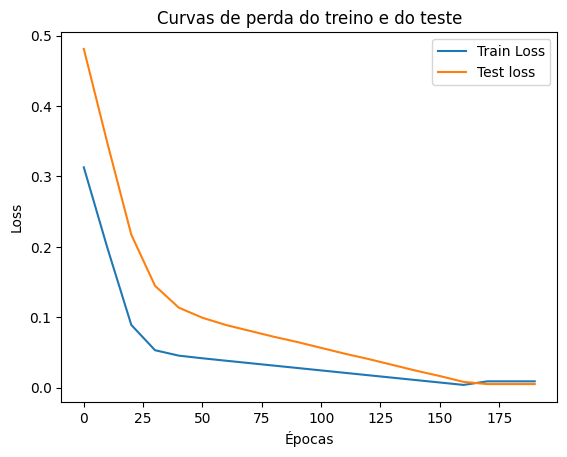

In [ ]:
# plot das curvas de perda
plt.plot(epoch_count, loss_values, label = "Train Loss")
plt.plot(epoch_count, test_loss_values, label = "Test loss")
plt.title("Curvas de perda do treino e do teste")
plt.ylabel("Loss")
plt.xlabel("Épocas")
plt.legend()

In [ ]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
weight, bias

(0.7, 0.3)

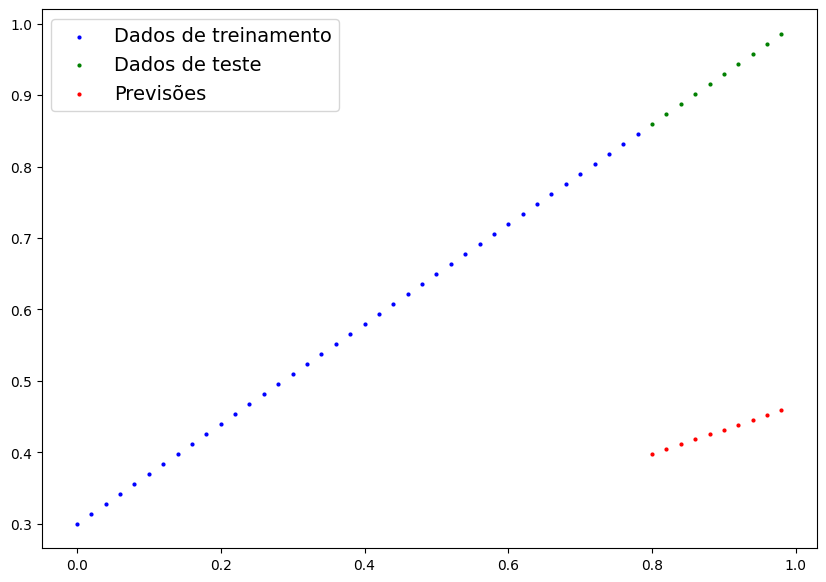

In [ ]:
plot_predictions(predictions = y_preds)

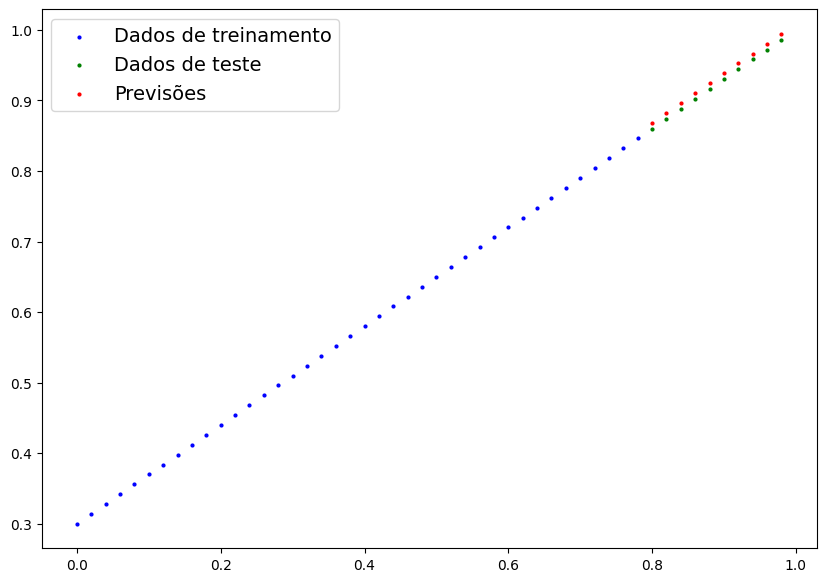

In [ ]:
plot_predictions(predictions = y_preds_new)

 ## Salvando um modelo em PyTorch

 Há três métodos principais que devemos saber sobre para salvar e carregar os modelos em PyTorch.

 1. `torch.save()` - permite que voce salve um objeto PyTorch em Python no formato pickle
 2. `torch.load()`- permite carregar um objeto PyTorch salvo
 3. `torch.nn.Module.load_state_dict()` - isso permite que voce carregue um state dictionary salvo de um modelo

In [ ]:
# Salvando nosso modelo PyTorch
from pathlib import Path

# 1. Crie um diretório de modelos
MODEL_PATH = Path("modelos")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

# 2. Criar um caminho para salvar o modelo
MODEL_NAME = "01_Pytorch_workflow_model_0.pth" 
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Salvar o state dict do modelo
print(f"Salvando o modelo em: {MODEL_SAVE_PATH}")
torch.save(obj = model_0.state_dict(),f =  MODEL_SAVE_PATH)

Salvando o modelo em: modelos/01_Pytorch_workflow_model_0.pth


In [ ]:
!ls -l modelos

total 4
-rw-rw-r-- 1 lucas lucas 2117 jun  5 23:10 01_Pytorch_workflow_model_0.pth


## Carregando um modelo PyTorch

Já que salvamos o `state_dict()` do nosso modelo  ao invés do modelo inteiro, criaremos uma nova instancia da nossa classe de modelo e carregaremos o `state_dict()` salvo

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# Para carregar o nosso modelo, intanciamos uma nova classe
loaded_model_0 = LinearRegressionModel()

# Carregamos o state_dict salvo de model_0(isso atualizará a nova instância com parâmetros atualizados)
loaded_model_0.load_state_dict(torch.load(f = MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# Fazendo algumas previsões com nosso modelo carregado
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds


tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [ ]:
# Comparar as previsões do modelo carregado com as previsões do modelo original
loaded_model_preds == y_preds_new

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 6. Juntando tudo isso

Vamos voltar às etapas acima e ver tudo em um só lugar.

In [ ]:
# Importando PyTorch e matplotlib
import torch 
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.12.0+cu130'

Criando um código independente de dispositivo.

Isso significa se tivermos acesso a GPU, nosso código a usará(paara uma potencial computação mais rápida).

Se não houver GPU disponível, o código terá como padrão o uso da CPU.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device}")

cpu


### 6.1 Dados

In [ ]:
# Criar algun sdados usando a fórmula de regressão linear y = weight * X + bias
weight = 0.5
bias = 0.1

# Criando valores em um intervalo
start = 0
end = 1
step = 0.02
# Criar X e y(features e labels)
X = torch.arange(start,end,step).unsqueeze(dim = 1) # Sem unsqueeze erros aparecerão
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.1000],
         [0.1100],
         [0.1200],
         [0.1300],
         [0.1400],
         [0.1500],
         [0.1600],
         [0.1700],
         [0.1800],
         [0.1900]]))

In [ ]:
# Dividindo os dados
div_train = int(0.8 * len(X))
X_train, y_train = X[:div_train], y[:div_train]
X_test, y_test = X[div_train:], y[div_train:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

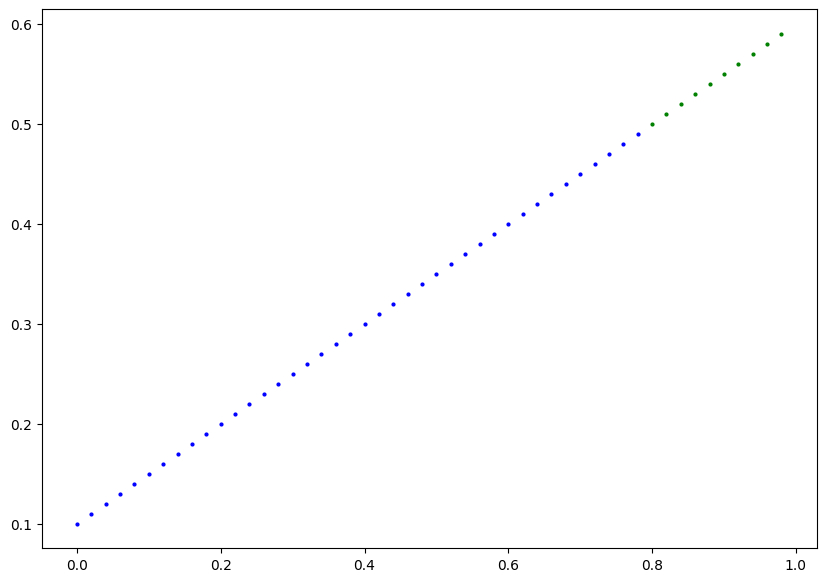

In [ ]:
# Plotando os dados
# NOte: Se você não tiver a função plot_predictions() carregada , isso resultará em erro
plot_predictions(X_train, y_train, X_test, y_test)


## 6.2 Construindo um modelo linear PyTorch

In [ ]:
# Criar um modelo linear por meio de umas subclasses de nn.Module
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Usaremos nn.Linear() para criar os parâmetros do modelo / também chamado de transformação linear, probing layer, fully connected layer, dense layer
        self.linear_layer = nn.Linear(in_features = 1,
                                      out_features = 1)
 
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
    
# Definir a manual_seed para que tenhamos reprodutibilidade    
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
# Checar o dispositivo atual do modelo
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

### 6.3 Treinamento

Para treinamento nós precisamos:
* Loss function
* Otimizador
* Loop de treinamento
* Loop de teste


In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model_1.parameters(), lr = 0.01)

In [ ]:
torch.manual_seed(42)

epocas = 200

# Colocar os dados no dispositivo de destino(device agnostic code for data)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

X_train = X_train.detach()
y_train = y_train.detach()
for epoca in range(epocas):
    model_1.train()

    y_pred = model_1(X_train)
    loss= loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        loss_test = loss_fn(test_pred, y_test)

    if epoca % 10 == 0:
        print(f"Epoca: {epoca} | Loss: {loss.item()} | Test Loss: {loss_test.item()}")

Epoca: 0 | Loss: 0.833177924156189 | Test Loss: 0.9519761800765991
Epoca: 10 | Loss: 0.7179681062698364 | Test Loss: 0.8172663450241089
Epoca: 20 | Loss: 0.6027581095695496 | Test Loss: 0.6825565695762634
Epoca: 30 | Loss: 0.487548291683197 | Test Loss: 0.5478467345237732
Epoca: 40 | Loss: 0.3723384439945221 | Test Loss: 0.41313689947128296
Epoca: 50 | Loss: 0.2571285367012024 | Test Loss: 0.2784270644187927
Epoca: 60 | Loss: 0.14191867411136627 | Test Loss: 0.1437171995639801
Epoca: 70 | Loss: 0.026708656921982765 | Test Loss: 0.00900720339268446
Epoca: 80 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoca: 90 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoca: 100 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoca: 110 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoca: 120 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoca: 130 | Loss: 0.005493368022143841 | Test Loss: 0.011843070387840271
Epoc

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.4923]])),
             ('linear_layer.bias', tensor([0.1085]))])

In [ ]:
weight, bias

(0.5, 0.1)

### 6.4 Fazendo e avaliando previsões 

In [ ]:
# Colocar o modelo no modo de avaliação
model_1.eval()

# Fazendo previsões nos dados de teste
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds    

tensor([[0.5023],
        [0.5122],
        [0.5220],
        [0.5319],
        [0.5417],
        [0.5516],
        [0.5614],
        [0.5712],
        [0.5811],
        [0.5909]])

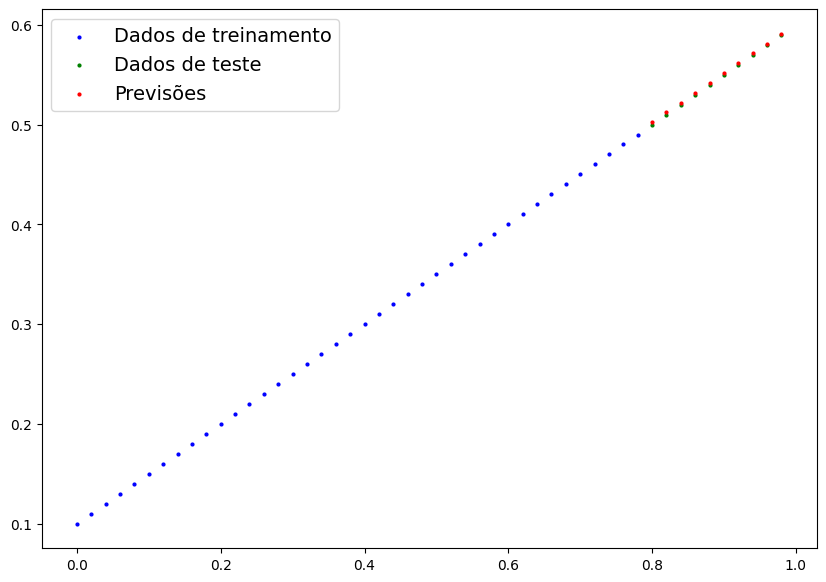

In [ ]:
# Checar as previsões do nosso modelo visualmente
plot_predictions(predictions = y_preds)


### 6.5 Salvando e carregando um modelo treinado 

In [ ]:
from pathlib import Path

# 1. Criar diretório de modelos
MODEL_PATH = Path("modelos")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

# 2. Criar um caminho para salvar o modelo
MODEL_NAME = "01_Pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Salvar o state dict do modelo
print(f"Salvando modelo em: {MODEL_SAVE_PATH}")
torch.save(obj = model_1.state_dict(), f = MODEL_SAVE_PATH)




Salvando modelo em: modelos/01_Pytorch_workflow_model_1.pth


In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.4923]])),
             ('linear_layer.bias', tensor([0.1085]))])

In [ ]:
# Carregar um modelo PyTorch

# Criamos uma nova instância do modelo de regressão linear V2
loaded_model_1 = LinearRegressionModelV2()

# Carregar o state dict do model_1 salvo
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))


# Colocar o modelo carregado  no dispositivo
loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
next(loaded_model_1.parameters()).device

device(type='cpu')

In [ ]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.4923]])),
             ('linear_layer.bias', tensor([0.1085]))])

In [ ]:
# Avaliar o modelo carregado
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## Exercicios e Extra-curricular

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"


In [ ]:
weight = 0.3
bias = 0.9
start = 0
end = 2
step = 0.01
X = torch.arange(start,end, step).unsqueeze(dim = 1)
y = weight * X + bias
len(X), len(y)

(200, 200)

In [ ]:
divisao_treino = int(0.8 * len(X))
X_treino, y_treino = X[:divisao_treino], y[:divisao_treino]
X_teste, y_teste = X[divisao_treino:], y[divisao_treino:]

len(X_treino), len(y_treino), len(X_teste), len(y_teste)

(160, 160, 40, 40)

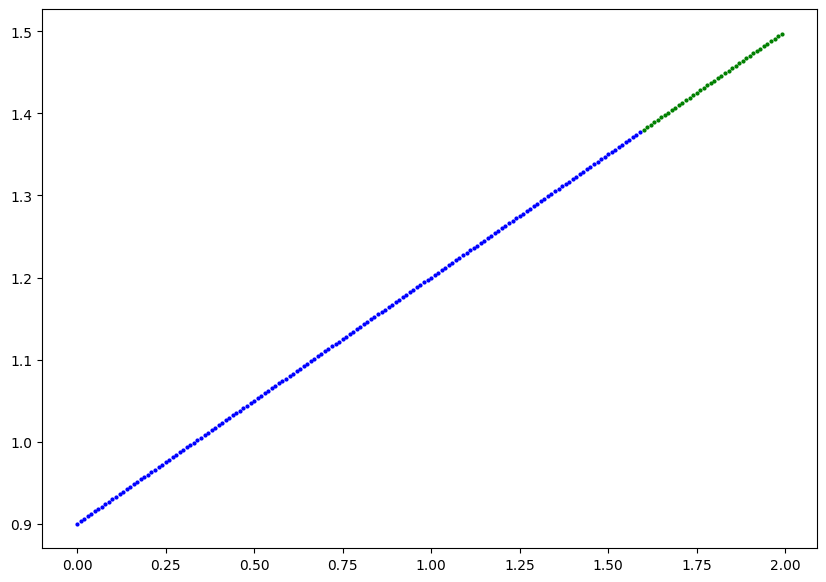

In [ ]:
plt.figure(figsize = (10,7))
plt.scatter(X_treino, y_treino, c = "b", s = 4 , label = "Dados de treinamento")
plt.scatter(X_teste, y_teste, c = "g", s = 4, label = "Dados de teste")

In [ ]:
class LinearRegressionModelV3(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features= 1,
                                out_features=1)
        
    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.linear(x)    

In [ ]:
model_2 = LinearRegressionModelV3()
model_2.state_dict()

OrderedDict([('linear.weight', tensor([[0.9545]])),
             ('linear.bias', tensor([0.0826]))])

In [ ]:
funcao_perda = nn.L1Loss()

otimizador = torch.optim.SGD

In [ ]:
otimizador = otimizador(params = model_2.parameters(), lr = 0.001)

In [ ]:
epocas = 30000
for epoca in range(epocas):
    y_previsoes_treino = model_2(X_treino)
    perda_treino = funcao_perda(y_previsoes_treino, y_treino)
    otimizador.zero_grad()
    perda_treino.backward()
    otimizador.step()

    model_2.eval()
    with torch.inference_mode():
        y_previsoes_teste = model_2(X_teste)
        perda_teste = funcao_perda(y_previsoes_teste, y_teste)

    if epoca % 20 == 0:
        print(f"época: {epoca} | Perda no treino: {perda_treino} | Perda no teste: {perda_teste}")


época: 0 | Perda no treino: 0.015168559737503529 | Perda no teste: 0.030180955305695534
época: 20 | Perda no treino: 0.013358714990317822 | Perda no teste: 0.026562700048089027
época: 40 | Perda no treino: 0.011548980139195919 | Perda no teste: 0.02292739227414131
época: 60 | Perda no treino: 0.009739186614751816 | Perda no teste: 0.019326146692037582
época: 80 | Perda no treino: 0.007929443381726742 | Perda no teste: 0.01569082774221897
época: 100 | Perda no treino: 0.006119645666331053 | Perda no teste: 0.012055513449013233
época: 120 | Perda no treino: 0.004309860989451408 | Perda no teste: 0.00845426321029663
época: 140 | Perda no treino: 0.0025001198519021273 | Perda no teste: 0.004818952176719904
época: 160 | Perda no treino: 0.0006903245812281966 | Perda no teste: 0.0011835992336273193
época: 180 | Perda no treino: 0.00122336414642632 | Perda no teste: 0.0007966548437252641
época: 200 | Perda no treino: 0.00122336414642632 | Perda no teste: 0.0007966548437252641
época: 220 | Per

In [ ]:
model_2.eval()
with torch.inference_mode():
    y_previsoes_model_2 = model_2(X_teste)

    

In [ ]:
y_previsoes_model_2[:5],y_teste[:5]

(tensor([[1.3784],
         [1.3814],
         [1.3844],
         [1.3874],
         [1.3904]]),
 tensor([[1.3800],
         [1.3830],
         [1.3860],
         [1.3890],
         [1.3920]]))

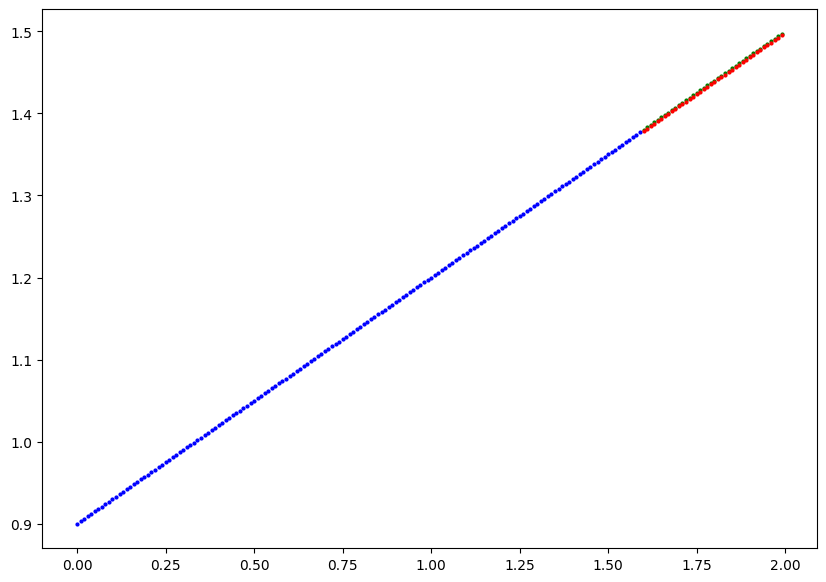

In [ ]:
plt.figure(figsize = (10,7))
plt.scatter(X_treino, y_treino, c = "b", s = 4 , label = "Dados de treinamento")
plt.scatter(X_teste, y_teste, c = "g", s = 4, label = "Dados de teste")
plt.scatter(X_teste, y_previsoes_model_2, c = "r", s = 4, label = "Previsões do modelo")

In [ ]:
from pathlib import Path

CAMINHO_MODELO = Path("modelos")
CAMINHO_MODELO.mkdir(parents = True, exist_ok = True)

NOME_MODELO = "01_Pytorch_workflow_model_2.pth"
CAMINHO_SALVO_MODELO = CAMINHO_MODELO / NOME_MODELO

print(f"Salvando modelo em: {CAMINHO_SALVO_MODELO}")
torch.save(obj = model_2.state_dict(), f = CAMINHO_SALVO_MODELO)

Salvando modelo em: modelos/01_Pytorch_workflow_model_2.pth


In [ ]:
loaded_model_2 = LinearRegressionModelV3()
loaded_model_2.load_state_dict(torch.load(CAMINHO_SALVO_MODELO))
y_preds_loaded = loaded_model_2(X_teste)
y_preds_loaded == y_previsoes_model_2

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

# 02. Classificação em redes neurais com Pytorch 

Classificação é um problema de prever se algo é uma coisa ou outra(pode ter varias coisas como opções)

## 1. Criar alguns dados de classificação e deixá-lo prontos

In [ ]:
import sklearn

In [ ]:
from sklearn.datasets import make_circles

# Criar 1000 amostras
n_amostras = 1000

# Criar circulos
X, y = make_circles(n_amostras,
                    noise = 0.03,
                    random_state=42)

In [ ]:
len(X), len(y)

(1000, 1000)

In [ ]:
print(f"Primeiras 5 amostras de X:{X[:5]}")
print(f"Primeiras 5 amostras de y:{ y[:5]}")


Primeiras 5 amostras de X:[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
Primeiras 5 amostras de y:[1 1 1 1 0]


In [ ]:
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [10]:
# Criar um DataFrame de dados circulares com Pandas
import pandas as pd
circulos = pd.DataFrame({"X1": X[:, 0], 
                         "X2": X[:,1],
                         "label": y})

circulos.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [11]:
circulos.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

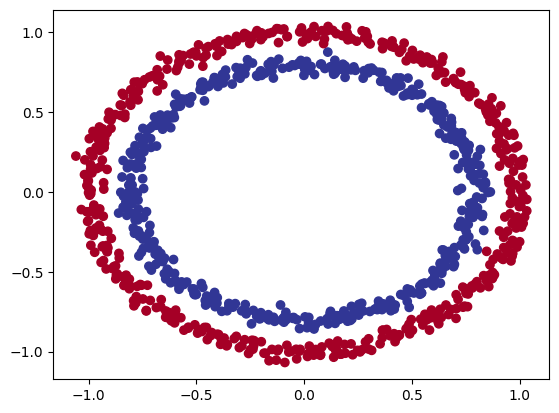

In [12]:
# visualize, visualize, visualize
import matplotlib.pyplot as plt
plt.scatter(x = X[:,0],
            y = X[:,1],
            c = y,
            cmap = plt.cm.RdYlBu)

**Nota:** Os dados que estamos trabalhando são frequentemente mencionados como um conjunto de dados de brinquedo(toy dataset), um dataset que seja pequeno o suficiente para ser experimentado, mas grande o suficiente para praticar os fundamentos

### 1.1  Checar formatos (shapes) de entrada e saída

In [13]:
X.shape, y.shape

((1000, 2), (1000,))

In [14]:
# Veja o primeiro exemplo de features e labels
X_sample = X[0]
y_sample = y[0]
X_sample, y_sample

print(f"Valores para ua amostra de X: {X_sample} e o mesmo para y: {y_sample}")
print(f"Shape de uma amostra de X: {X_sample.shape}, o mesmo para y: {y_sample.shape}")

Valores para ua amostra de X: [0.75424625 0.23148074] e o mesmo para y: 1
Shape de uma amostra de X: (2,), o mesmo para y: ()


### 1.2 Transformando dados em tensores e criar divisões de treino e teste

In [15]:
import torch
torch.__version__

'2.12.0+cu130'

In [16]:
type(X)

numpy.ndarray

In [17]:
# Tranformar dados em tensores
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]


(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [18]:
type(X), type(y), X.dtype, y.dtype

(torch.Tensor, torch.Tensor, torch.float32, torch.float32)

In [19]:
# Separar dados em conjuntos de treinamento e teste
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(X,
                                                        y,
                                                        test_size=0.2,
                                                        random_state = 42)


In [20]:
len(X_treino), len(X_teste), len(y_treino), len(y_teste)

(800, 200, 800, 200)

## 2 Construindo um modelo

Vamos construir um modelo para classificar nossos pontos azuis e vermelhos.

Para isso, nós queremos:
1. Configurar o código agnóstico do dispositivo, portanto nosso codigo dera executado em um acelerador(GPU) se houver uma, se não houver será executado na CPU
2. Construir o modelo(pela subclasse `nn.Module`)
3. Definir a função de perda e o otimizador
4. Criar um loops de treinamento e de teste



In [1]:
import torch
from torch import nn

# Fazer o código agnóstico
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [22]:
X_treino

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

Agora nós temos o código agnóstico de dispositivo configurado, vamos criar um modelo que:

1. Subclasse de `nn.Module`(quase todos os modelos são da subclasse Pytorch `nn.Module`)
2. Criar 2 camadas `nn.Linear()` e queremos que eles sejam capazes de lidar com os formatos dos nossos dados
3. Definir o método `forward()` que delimita o forward pass(ou forward computation) do modelo
4. Instanciar uma instância da nossa classe do modelo e envia-la para o `dispositivo` alvo



In [23]:
X_treino.shape

torch.Size([800, 2])

In [24]:
# 1. Construir um modelo com a subclasse nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Criar duas camadas nn.Linear capazes de manipular as formas dos nossos dados
        self.layer_1 = nn.Linear(in_features = 2, out_features = 5) # pega duas entradas e transforma em cinco saídas
        self.layer_2 = nn.Linear(in_features = 5, out_features = 1) # recebe 5 saídas da camada anterior e transforma em uma saída(mesmo formato de y)

    # 3. Definindo o método forward
    def forward(self, x):
        return self.layer_2(self.layer_1(x)) # x -> layer_1 -> layer_2 -> saída
    

# 4. Instanciar uma classe do nosso modelo e enviá-la para o dispositivo de destino
model_1_0 = CircleModelV0().to(device)
model_1_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [25]:
device

'cpu'

In [26]:
next(model_1_0.parameters()).device

device(type='cpu')

In [ ]:
# Vamos replicar o modelo acima usando nn.Sequential()
model_1_0 = nn.Sequential(
    nn.Linear(in_features = 2, out_features = 5),
    nn.Linear(in_features= 5, out_features = 1)
).to(device)

model_1_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [28]:
model_1_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.2441, -0.2311],
                      [ 0.3191, -0.2892],
                      [-0.6997, -0.0566],
                      [ 0.3490, -0.6832],
                      [-0.3242, -0.2404]])),
             ('0.bias', tensor([ 0.0053, -0.2165, -0.0715,  0.6465,  0.0517])),
             ('1.weight',
              tensor([[-0.3341,  0.3253,  0.2213, -0.1493,  0.3320]])),
             ('1.bias', tensor([0.0066]))])

In [29]:
# Fazer algumas previsões com o modelo
with torch.inference_mode():
    untrained_preds = model_1_0(X_teste.to(device))
print(f"tamanho das previsões: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Tamanho das amostras de teste: {len(X_teste)}, Shape: {X_teste.shape}")
print(f"\nPrimeiras 10 previsões:\n{torch.round(untrained_preds[:10])}")
print(f"\n Primeiros 10 rótulos(labels):\n{y_teste[:10]}")


tamanho das previsões: 200, Shape: torch.Size([200, 1])
Tamanho das amostras de teste: 200, Shape: torch.Size([200, 2])

Primeiras 10 previsões:
tensor([[-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.]])

 Primeiros 10 rótulos(labels):
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [30]:
X_teste[:10] , y_teste[:10] 

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### 2.1 Configurar a função de perda e o otimizador

Qual função de perda ou otimizador deve-se usar?

De novo... isso é especifivo do problema.

Por exemplo para regressão você pode escolher o MAE ou MSE (mean absolute error or mean squared error).

Para classificação voce pode escolher a entropia cruzada binária(binary cross entropy) ou entropia cruzada categórica(cross entropy).

Como um lembrete, a função de perda mede o quanto as previsões do modelo estão **erradas**.

E para os otimizadores, dois dos mais comuns e úteis são o SGD e o Adam, no entanto pytorch tem muitas opções integradas.

* Para a função de perda, vamos usar `torch.nn.BCEWithLogitsLoss()`
* Para diferentes otimizadores ver `torch.optim()`

In [31]:
#loss_fn = nn.BCELoss() #BCELoss = requer que as entradas tenham passado pela função de ativação sigmoide antes de serem inseridas na BCELoss
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss tem a ativação sigmoide incorporada

otimizador = torch.optim.SGD(params = model_1_0.parameters(),
                             lr = 0.001
                             )

In [32]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/ len(y_pred)) * 100
    return acc

## 3. Treinamento de um modelo

Para treinar nosso modelo, precisaremos criar um loop de treinamento com as seguintes etapas:
1. Forward pass(inferencia)
2. Calcular a perda
3. Zerar os gradientes
4. Backpropagation
5. Otimizador(descida do gradiente)


### 3.1 Vamos passar de logits -> probabilidade de previsão -> previsão de rótulos

Os resultados de nosso modelo serão **logits**.

Podemos converter esses **logits** em **probabilidades de previsão** passando por eles para terem algum tipo de função de ativação(sigmoide para entropia cruzada binaria e softmax para clasificação multiclasse).

Então nós podemos converter as probabilidades de previsão do nosso modelo em **previsão de rótulos** arredondando-os ou usando `argmax()`.

In [33]:
# Veja as 5 primeiras saídas da inferência nos dados de teste
model_1_0.eval()
with torch.inference_mode():
    y_logits = model_1_0(X_teste.to(device))[:5]
y_logits

tensor([[-0.1172],
        [-0.1697],
        [-0.0677],
        [-0.1309],
        [-0.2074]])

In [34]:
y_teste[:5]

tensor([1., 0., 1., 0., 1.])

In [35]:
# Usar a funçao de ativação sigmóide em nosso modelo logits para transformá-los em probabilidades de previsão
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4707],
        [0.4577],
        [0.4831],
        [0.4673],
        [0.4483]])

Para nossos valores de probabilidade de previsão, precisamos realizar um arredondamento de range-style neles:
* `y_pred_probs` >= 0.5, `y=1` (classe 1)
* `y_pred_probs` < 0.5, `y=0` (classe 0)

In [36]:
# Encontrando os rótulos previstos
y_preds = torch.round(y_pred_probs)

# Por completo(logits -> probabilidade das previsoes -> previsoes dos rótulos(labels))
y_pred_labels = torch.round(torch.sigmoid(model_1_0(X_teste.to(device))[:5]))

# Checar se há igualdade
print(torch.equal(y_preds.squeeze(), y_pred_labels.squeeze()))

# Fazer isso para se livrar da dimensão extra mais uma vez
y_preds.squeeze()

True


tensor([0., 0., 0., 0., 0.])

In [37]:
y_teste[:5]

tensor([1., 0., 1., 0., 1.])

### 3.2 Construindo loops de treinamento e teste

In [38]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Definir o número de épocas
epochs = 100

# Vamos colocar os dados no dispositivo de destino
X_treino, y_treino = X_treino.to(device), y_treino.to(device)
X_teste, y_teste = X_teste.to(device), y_teste.to(device)

# Criar nosso loop de treinamento e avaliação
for epoch in range(epochs):
    ### Treinamento
    model_1_0.train()

    # 1. Forward pass
    y_logits = model_1_0(X_treino).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # transformar logits -> probabilidades de previsão -> probabilidade de rótulos


    # 2. Calcular a perda/acurácia
    #loss = loss_fn(torch.sigmoid(y_logits), # nn.BCELoss espera probabilidades de previsão como entrada
    #               y_treino)
    loss = loss_fn(y_logits, # nn.BCEWithLogitsLoss espera logits brutos como entrada 
                   y_treino)
    acc = accuracy_fn(y_true = y_treino,
                      y_pred = y_pred)
    

    # 3. Otimizador zero grad
    otimizador.zero_grad()

    # 4. Loss backward(backpropagation)
    loss.backward()

    # 5. Etapa do otimizador(descida do gradiente)
    otimizador.step()

    ### Teste
    model_1_0.eval()
    with torch.inference_mode():
        # 1. Forward pass(inferência)
        test_logits = model_1_0(X_teste).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calcular a perda do teste/precisão
        test_loss = loss_fn(test_logits,
                            y_teste)
        test_acc = accuracy_fn(y_true = y_teste,
                            y_pred= test_pred)
    # Printar o que esta acontecendo
    if epoch % 10 == 0:
        print(f"Época: {epoch} | Perda: {loss:.5f} | Acc: {acc:.2f}% | Perda do teste: {test_loss:.5f} | Precisão no teste: {test_acc:.2f}%")







Época: 0 | Perda: 0.69755 | Acc: 50.00% | Perda do teste: 0.69575 | Precisão no teste: 50.00%
Época: 10 | Perda: 0.69752 | Acc: 50.00% | Perda do teste: 0.69572 | Precisão no teste: 50.00%
Época: 20 | Perda: 0.69748 | Acc: 50.00% | Perda do teste: 0.69568 | Precisão no teste: 50.00%
Época: 30 | Perda: 0.69745 | Acc: 50.00% | Perda do teste: 0.69565 | Precisão no teste: 50.00%
Época: 40 | Perda: 0.69742 | Acc: 50.00% | Perda do teste: 0.69562 | Precisão no teste: 50.00%
Época: 50 | Perda: 0.69739 | Acc: 50.00% | Perda do teste: 0.69559 | Precisão no teste: 50.00%
Época: 60 | Perda: 0.69735 | Acc: 50.00% | Perda do teste: 0.69556 | Precisão no teste: 50.00%
Época: 70 | Perda: 0.69732 | Acc: 50.00% | Perda do teste: 0.69552 | Precisão no teste: 50.00%
Época: 80 | Perda: 0.69729 | Acc: 50.00% | Perda do teste: 0.69549 | Precisão no teste: 50.00%
Época: 90 | Perda: 0.69726 | Acc: 50.00% | Perda do teste: 0.69546 | Precisão no teste: 50.00%


## 4. Fazendo previsões e avaliando o modelo

Pelas métricas parece que o nosso modelo não está aprendendo nada...

Para inspecionar isso vamos fazer algumas previsões e torná-las visuais!

Em outras palavras, "Visualize, visualize, visualize"

Para fazer isso, vamos importar uma função chamada `plot_decision_boundary()`   - https://github.com/mrdbourke/pytorch-deep-learning/blob/main/helper_functions.py


In [9]:
import requests
from pathlib import Path

# Baixe as "helper functions" do repositorio Learn Pytorch (se ainda não tiver sido baixado)
if Path("helper_functions.py").is_file():
    print(f"helper_functions.py já existe, skipando o download")
else:
    print(f"Download helper_functions.py")
    request =  requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary



helper_functions.py já existe, skipando o download


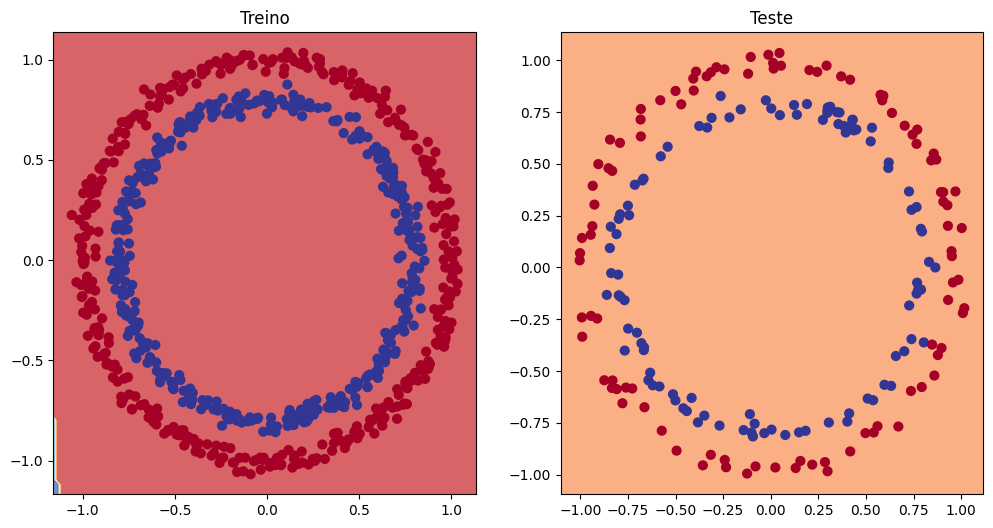

In [40]:
# Plotar o limite de decisão do modelo
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Treino")
plot_decision_boundary(model_1_0, X_treino, y_treino)
plt.subplot(1,2,2)
plt.title("Teste")
plot_decision_boundary(model_1_0, X_teste, y_teste)






## 5. Melhorando um modelo(a partir de uma perspectiva do modelo)

* Adicionar mais camadas - dar ao modelo mais chances de aprender sobre os padrões nos dados
* Adicionar mais unidade ocultas - ir de 5 unidades ocultas para 10
* Inferir por mais tempo, dar ao modelo mais chances de aprender
* Mudar as funções de ativação
* Mudar o learning rate(passo da descida do gradiente)
* Trocar a função de perda

Essas opções são todas da perspectiva do nosso modelo, porque elas lidam diretamente com o modelo e não com os dados

E como todas essas opções são valores, nós (como engenheiros de machine learning e cientista de dados ) podemos mudar,  o que podemos mudar (referenciar) são chamados de **hiperparametros**

Vamos tentar melhorar nosso modelo:
* Adicionando mais unidades ocultas: 5 -> 10
* Aumentando o número de camadas: 2 -> 3
* Aumentando o número de épocas: 100 -> 1000



In [41]:
model_1_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.2446, -0.2313],
                      [ 0.3196, -0.2891],
                      [-0.6994, -0.0565],
                      [ 0.3488, -0.6833],
                      [-0.3237, -0.2403]])),
             ('0.bias', tensor([ 0.0039, -0.2152, -0.0707,  0.6459,  0.0530])),
             ('1.weight',
              tensor([[-0.3345,  0.3248,  0.2199, -0.1466,  0.3316]])),
             ('1.bias', tensor([0.0105]))])

In [42]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer_3 = nn.Linear(in_features = 10, out_features = 1) 
    def forward(self, x):
        #z = self.layer_1(x)
        #z = self.layer_2(z)
        #z = self.layer_3(z)
        return self.layer_3(self.layer_2(self.layer_1(x))) # essa maneira de escrever operações  aproveita os aumentos de velocidade nos bastidores
    

model_1_1 = CircleModelV1().to(device)
model_1_1


CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [43]:
model_1_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.2446, -0.2313],
                      [ 0.3196, -0.2891],
                      [-0.6994, -0.0565],
                      [ 0.3488, -0.6833],
                      [-0.3237, -0.2403]])),
             ('0.bias', tensor([ 0.0039, -0.2152, -0.0707,  0.6459,  0.0530])),
             ('1.weight',
              tensor([[-0.3345,  0.3248,  0.2199, -0.1466,  0.3316]])),
             ('1.bias', tensor([0.0105]))])

In [44]:
model_1_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]])),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984])),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1

In [45]:
loss_fn_1 = nn.BCEWithLogitsLoss()
otimizador_1 = torch.optim.SGD(params = model_1_1.parameters(), lr = 0.1)

In [46]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epocas = 1000
X_treino, y_treino = X_treino.to(device), y_treino.to(device)
X_teste, y_teste = X_teste.to(device), y_teste.to(device)

for epoca in range(epocas):
    model_1_1.train()
    logits_1 = model_1_1(X_treino).squeeze()
    y_pred_1 = torch.round(torch.sigmoid(logits_1))
    loss = loss_fn_1(logits_1, y_treino)
    acc = accuracy_fn(y_true = y_treino, y_pred = y_pred_1)
    otimizador_1.zero_grad()
    loss.backward()
    otimizador_1.step()


    model_1_1.eval()
    with torch.inference_mode():
        logits_teste = model_1_1(X_teste).squeeze()
        y_pred_1_teste = torch.round(torch.sigmoid(logits_teste))
        loss_teste = loss_fn_1(logits_teste, y_teste)
        acc_teste = accuracy_fn(y_true = y_teste, y_pred = y_pred_1_teste)
    if(epoca % 100 == 0):
        print(f" Época: {epoca} | Perda no treino: {loss:.5f} | Acurácia no treino: {acc:.2f}% | Perda no teste: {loss_teste:.5f} | Acurácia no teste: {acc_teste:.2f}%")



 Época: 0 | Perda no treino: 0.69396 | Acurácia no treino: 50.88% | Perda no teste: 0.69261 | Acurácia no teste: 51.00%
 Época: 100 | Perda no treino: 0.69305 | Acurácia no treino: 50.38% | Perda no teste: 0.69379 | Acurácia no teste: 48.00%
 Época: 200 | Perda no treino: 0.69299 | Acurácia no treino: 51.12% | Perda no teste: 0.69437 | Acurácia no teste: 46.00%
 Época: 300 | Perda no treino: 0.69298 | Acurácia no treino: 51.62% | Perda no teste: 0.69458 | Acurácia no teste: 45.00%
 Época: 400 | Perda no treino: 0.69298 | Acurácia no treino: 51.12% | Perda no teste: 0.69465 | Acurácia no teste: 46.00%
 Época: 500 | Perda no treino: 0.69298 | Acurácia no treino: 51.00% | Perda no teste: 0.69467 | Acurácia no teste: 46.00%
 Época: 600 | Perda no treino: 0.69298 | Acurácia no treino: 51.00% | Perda no teste: 0.69468 | Acurácia no teste: 46.00%
 Época: 700 | Perda no treino: 0.69298 | Acurácia no treino: 51.00% | Perda no teste: 0.69468 | Acurácia no teste: 46.00%
 Época: 800 | Perda no tre

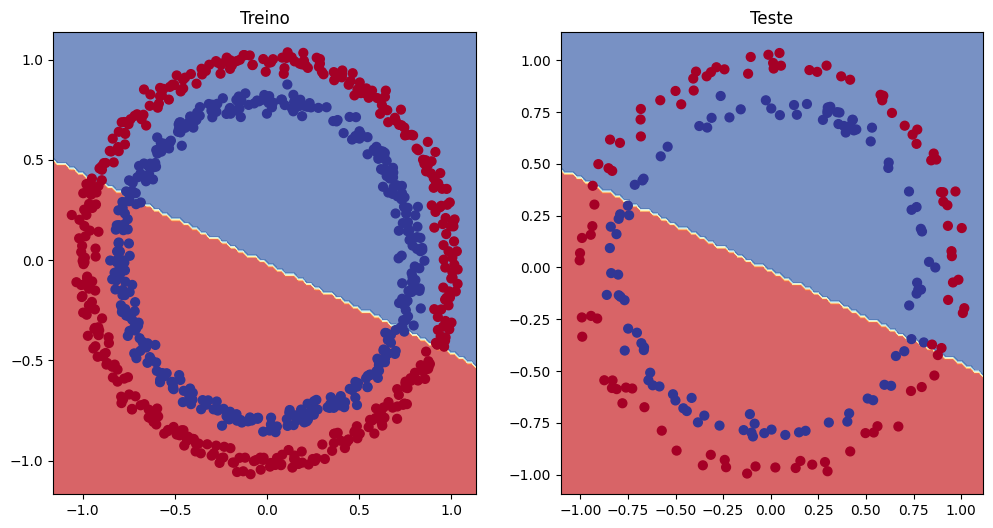

In [47]:
# Plotar o limite de decisão
# Plotar o limite de decisão do modelo
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Treino")
plot_decision_boundary(model_1_1, X_treino, y_treino)
plt.subplot(1,2,2)
plt.title("Teste")
plot_decision_boundary(model_1_1, X_teste, y_teste)






### 5.1 Vamos preparar os dados para ver se o nosso modelo pode se ajustar a uma linha reta

Uma maneira de solucionar problemas maiores é testando problemas menores

In [48]:
# Criando alguns dados(mesmo que a seção 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Criando dados
X_regression = torch.arange(start,end, step).unsqueeze(dim = 1)
y_regression = weight * X_regression + bias # Fórmula da regressão linear (sem epsilon)

# Verificar os dados
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [49]:
# Criar divisões de treinamento e teste
train_split = int(len(X_regression)* 0.8)
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression , y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Checar os comprimentos
len(X_train_regression), len(X_test_regression), len(y_train_regression), len(y_test_regression)

(80, 20, 80, 20)

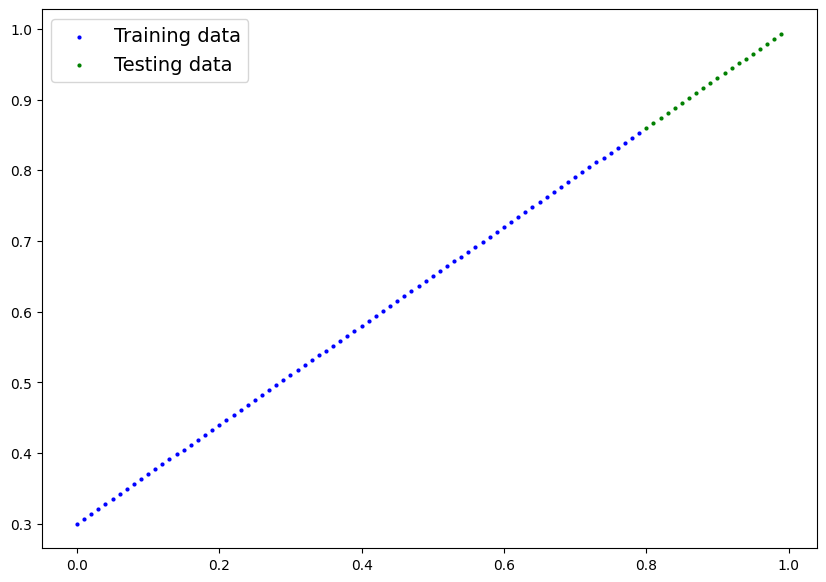

In [50]:
plot_predictions(train_data = X_train_regression,
                 train_labels = y_train_regression,
                 test_data = X_test_regression,
                 test_labels = y_test_regression)

In [51]:
X_train_regression[:10], y_train_regression[:10]

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400],
         [0.0500],
         [0.0600],
         [0.0700],
         [0.0800],
         [0.0900]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280],
         [0.3350],
         [0.3420],
         [0.3490],
         [0.3560],
         [0.3630]]))

### 5.2 Ajustando `model_1_1` à uma linha reta

In [52]:
# Mesma arquitetura do modelo 1 (mas usando nn.Sequential())
model_1_2 = nn.Sequential(nn.Linear(in_features = 1, out_features = 10),
                          nn.Linear(in_features = 10, out_features = 10),
                          nn.Linear(in_features = 10, out_features = 1)).to(device)

model_1_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [53]:
# Função perda e otimizador
loss_fn = nn.L1Loss() # MAE loss com dados de regressão
optimizer = torch.optim.SGD(params = model_1_2.parameters(),
                            lr = 0.01)

In [54]:
# Treinar o modelo
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Configurar o número de épocas
epochs = 1000

# Colocar nossos dados no dispositivo de destino
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

# Treino
for epoch in range(epochs):
    model_1_2.train()
    y_pred =  model_1_2(X_train_regression)
    loss = loss_fn(y_pred, y_train_regression)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_1_2.eval()
    with torch.inference_mode():
        y_pred_test = model_1_2(X_test_regression)
        test_loss = loss_fn(y_pred_test, y_test_regression)
    if epoch % 100 == 0:
        print(f"Época: {epoch} | Perda: {loss:.5f} | Perda no teste: {test_loss:.5f}")



Época: 0 | Perda: 0.75986 | Perda no teste: 0.91103
Época: 100 | Perda: 0.02858 | Perda no teste: 0.00081
Época: 200 | Perda: 0.02533 | Perda no teste: 0.00209
Época: 300 | Perda: 0.02137 | Perda no teste: 0.00305
Época: 400 | Perda: 0.01964 | Perda no teste: 0.00341
Época: 500 | Perda: 0.01940 | Perda no teste: 0.00387
Época: 600 | Perda: 0.01903 | Perda no teste: 0.00379
Época: 700 | Perda: 0.01878 | Perda no teste: 0.00381
Época: 800 | Perda: 0.01840 | Perda no teste: 0.00329
Época: 900 | Perda: 0.01798 | Perda no teste: 0.00360


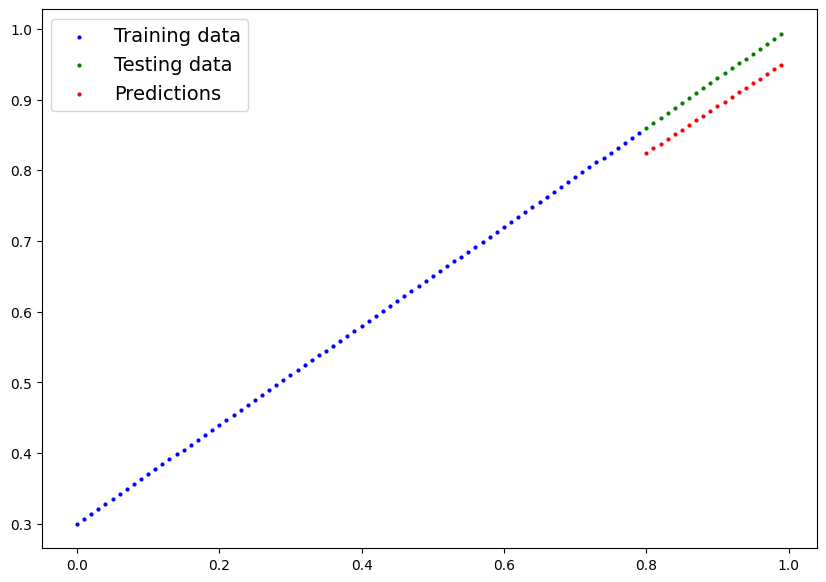

In [55]:
# Ligar o método de avaliação
model_1_2.eval()

# Fazer previsões (inferencia)
with torch.inference_mode():
    y_preds = model_1_2(X_test_regression)

# Plotar os dados e as previsões
plot_predictions(train_data = X_train_regression.cpu(),
                  train_labels = y_train_regression.cpu(),
                  test_data = X_test_regression.cpu(),
                  test_labels = y_test_regression.cpu(),
                  predictions = y_preds.cpu())

## 6. A peça que faltava em nossso modelo: não linearidade

"Quais padões você poderia desenhar se fosse lhe dado um quantidade infinita de linhas retas e não retas?"

Ou em termos de machine learning, infinitas (mas na realidade é finito) de funções lineares e não lineares

### 6.1 Recriando dados não lineares (circulos vermelhos e azuis)

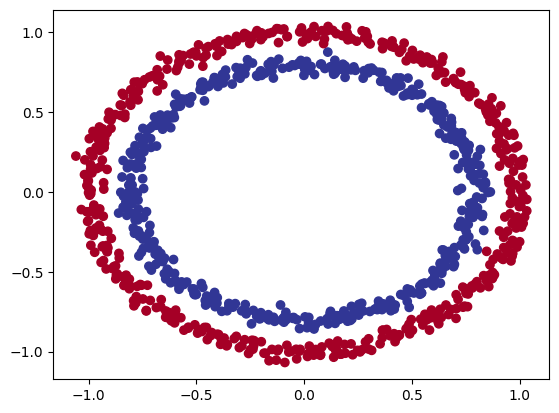

In [56]:
# Criar e plotar dados
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state = 42)

plt.scatter(X[:,0], X[:,1], c = y, cmap = plt.cm.RdYlBu)

In [57]:
# Converter os dados para tensores e depois para divisõpes de treinamento e teste
import torch
from sklearn.model_selection import train_test_split

# Transformar dados em tensores
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Separar em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                    random_state = 42)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Construindo um modelo com não linearidade

* Linear = linhas retas
* Não linear = linhas não retas

Redes neurais artificiais são uma grande combinação de  funções lineares (retas) e não lineares(não retas) que são potencialmente capazes de encontrar padrões nos dados.

In [58]:
# Criar um modelo com funções de ativações não lineares
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
        self.relu = nn.ReLU() # Relu é uma função de ativação não linear

    def forward(self, x):
        # Onde devemos colocar nossas funções de ativações não lineares
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_1_3 = CircleModelV2().to(device)
model_1_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [59]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_1_3.parameters(),
                            lr = 0.1)

### 6.3  Treinamento de um modelo com não-linearidade

In [60]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 1000

for epoch in range(epochs):
    model_1_3.train()
    y_logits = model_1_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true = y_train, y_pred = y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_1_3.eval()
    with torch.inference_mode():
        test_logits = model_1_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true = y_test, y_pred = test_pred)
    if epoch % 100 == 0:
        print(f"Época: {epoch} | Loss: {loss:.4f} | Acurácia treino: {acc:.2f}% | Loss teste: {test_loss:.4f} | Acurácia teste: {test_acc:.2f}%")

Época: 0 | Loss: 0.6929 | Acurácia treino: 50.00% | Loss teste: 0.6932 | Acurácia teste: 50.00%
Época: 100 | Loss: 0.6912 | Acurácia treino: 52.88% | Loss teste: 0.6910 | Acurácia teste: 52.50%
Época: 200 | Loss: 0.6898 | Acurácia treino: 53.37% | Loss teste: 0.6894 | Acurácia teste: 55.00%
Época: 300 | Loss: 0.6879 | Acurácia treino: 53.00% | Loss teste: 0.6872 | Acurácia teste: 56.00%
Época: 400 | Loss: 0.6852 | Acurácia treino: 52.75% | Loss teste: 0.6841 | Acurácia teste: 56.50%
Época: 500 | Loss: 0.6810 | Acurácia treino: 52.75% | Loss teste: 0.6794 | Acurácia teste: 56.50%
Época: 600 | Loss: 0.6751 | Acurácia treino: 54.50% | Loss teste: 0.6729 | Acurácia teste: 56.00%
Época: 700 | Loss: 0.6666 | Acurácia treino: 58.38% | Loss teste: 0.6632 | Acurácia teste: 59.00%
Época: 800 | Loss: 0.6516 | Acurácia treino: 64.00% | Loss teste: 0.6476 | Acurácia teste: 67.50%
Época: 900 | Loss: 0.6236 | Acurácia treino: 74.00% | Loss teste: 0.6215 | Acurácia teste: 79.00%


### 6.4 Avaliando nosso modelo com funções de ativação não lineares

In [61]:
# Inferência
model_1_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_1_3(X_test))).squeeze()

y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

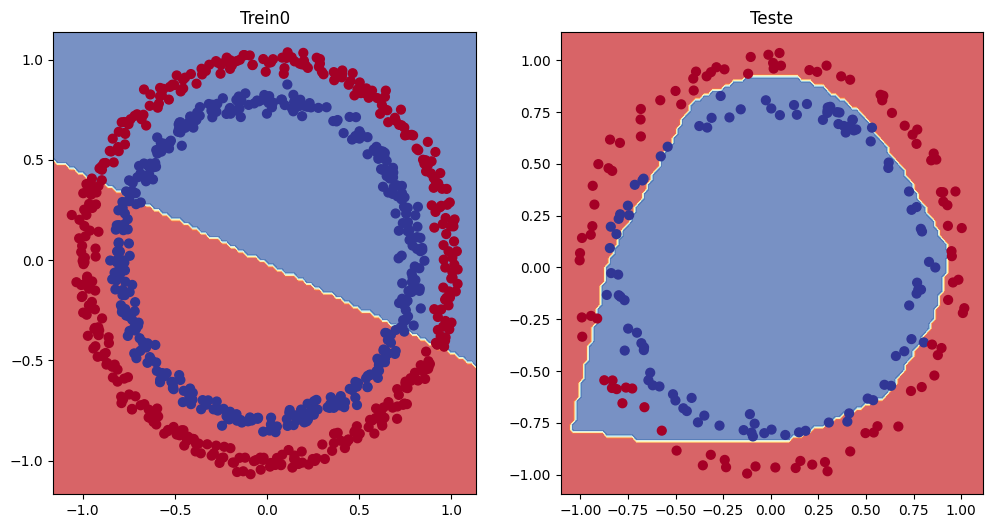

In [62]:
# Plotar os limites de decisão do modelo
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Trein0")
plot_decision_boundary(model_1_1, X_train, y_train) # model_1_1 = sem não linearidade
plt.subplot(1,2,2)
plt.title("Teste")
plot_decision_boundary(model_1_3, X_test, y_test) # model_1_3 = com não linearidade

## 7. Replicando funções de ativação não lineares

Redes neurais, em vez de dizermos ao modelo o que ele deve aprender, fornecemos a ele as ferramentas para descobrir padrões nos dados e assim tenta descobrir os melhores padões por conta própria.

E essas ferramentas são funções lineares e não lineares

In [63]:
# Criando um tensor
A = torch.arange(-10,10,1, dtype = torch.float32)
A.dtype

torch.float32

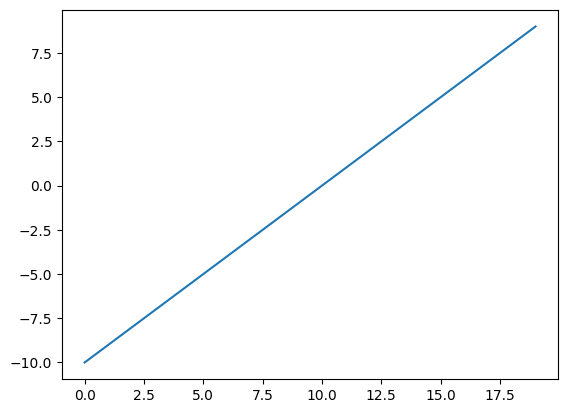

In [64]:
# Visualizar esse tensor
plt.plot(A)

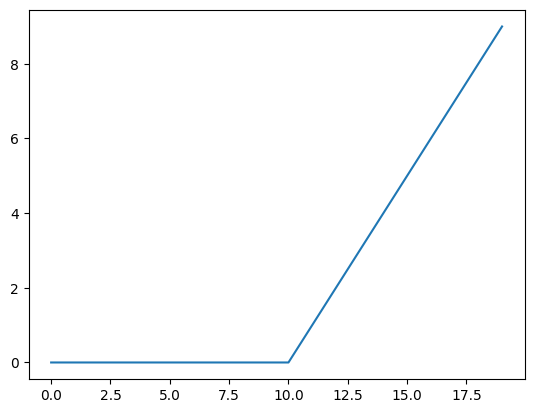

In [65]:
plt.plot(torch.relu(A))

In [66]:
def relu(x: torch.Tensor) -> torch.Tensor:
    return torch.maximum(torch.tensor(0), x) # entradas tem que ser tensores

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

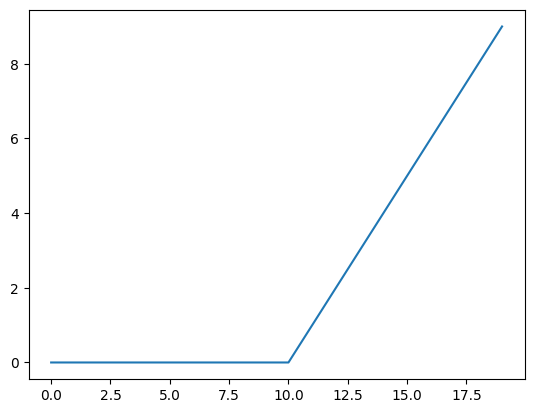

In [67]:
# Plot  função de ativação ReLU
plt.plot(relu(A))

In [68]:
# Agora vamos fazer o mesmo para sigmoid
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

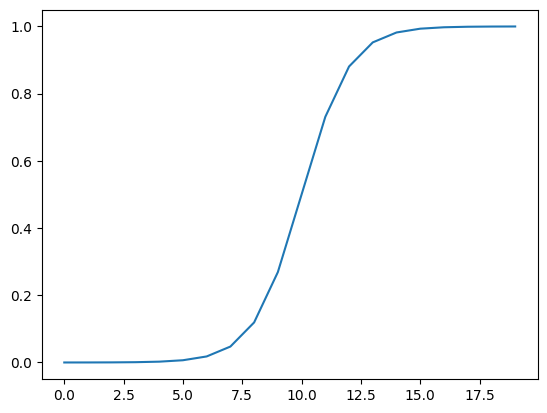

In [69]:
plt.plot(torch.sigmoid(A))

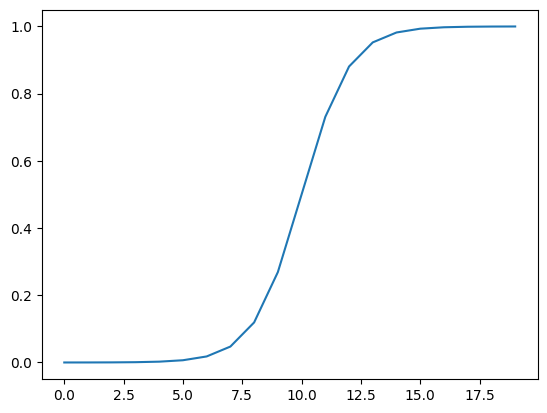

In [70]:
plt.plot(sigmoid(A))

## 8. Colocando tudo junto com um problema de classificação multiclasse

* Classificação binária = uma coisa ou outra(gato ou cachorro, spam ou não spam) 
* Classificação multiclasse = mais que uma coisa ou outra( cachorro ou gato ou galinha)

### 8.1 Criação de um conjunto brinquedo de dados multiclasse

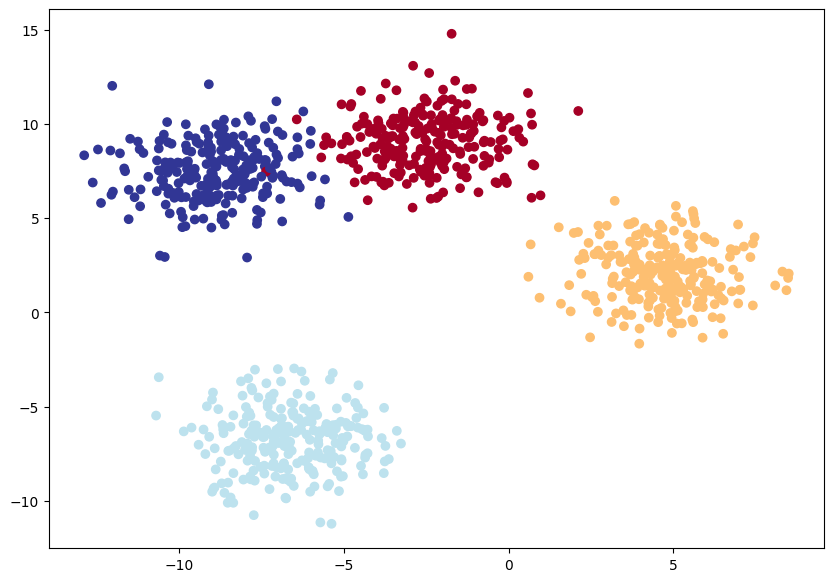

In [71]:
# Importar dependencias
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Definir o número de hiperparametros para a criação de dados
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Criar dados multiclasse
X_blob, y_blob = make_blobs(n_samples = 1000,
                            n_features = NUM_FEATURES,
                            centers = NUM_CLASSES,
                            cluster_std = 1.5,
                            random_state = RANDOM_SEED) # adicionar um pouco de aleatoriedade aos dados

# 2. Transformar dados em tensores
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# 3. Dividindo em treino e teste
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size = 0.2,
                                                                        random_state = RANDOM_SEED)

# 4. Plotar os dados(visualize, visualize, visualize)
plt.figure(figsize = (10,7))
plt.scatter(X_blob[:, 0], X_blob[:,1], c = y_blob, cmap = plt.cm.RdYlBu)





### 8.2 Criando um modelo de classificação multiclasse no PyTorch

In [72]:
# Criar o código independente de dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [73]:
# Criar um modelo de classificação multiclasse
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units = 8):
        """Inicializar o modelo de classificação multiclasse.
        Args:
            input_features (int): Numero de recursos de entrada para o modelo
            output_features (int): Numero de recursos de saida do modelo (número de classes de saída)
            hidden_units (int): Numero de unidades ocultas entre camadas, default = 8
        """
        super().__init__()
        self.linear_layer_stack  = nn.Sequential(
            nn.Linear(in_features = input_features, out_features = hidden_units),
            #nn.ReLU(),
            nn.Linear(in_features = hidden_units, out_features = hidden_units),
            #nn.ReLU(),
            nn.Linear(in_features = hidden_units, out_features = output_features)
        )
    def forward(self, x):
        return self.linear_layer_stack(x)

# Ciar uma instancia do BlobModel e enviá-la ao dispositivo de destino
model_1_4 = BlobModel(input_features = 2, 
                      output_features = 4,
                      hidden_units = 8).to(device)

model_1_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [74]:
X_blob_train.shape, y_blob_train[:5]

(torch.Size([800, 2]), tensor([1, 0, 2, 2, 0]))

In [75]:
torch.unique(y_blob_train)

tensor([0, 1, 2, 3])

### 8.3 Criar a função de perda e um otimizador para um modelo de classificação multiclasse


In [76]:
# Criar uma função de perda para classificação multiclasse - função de perda mede quanto as previsões do nosso modelo estão erradas
loss_fn = nn.CrossEntropyLoss()

# Criar um otimizador para classificação multiclasse - otimizador atualiza os paramêtros do nosso modelo para tentar reduzir a perda
optimizer = torch.optim.SGD(params = model_1_4.parameters(),
                            lr = 0.1) # learning rate é um hiperparametro, logo podemos mudar

### 8.4 Obter probabilidades de previsão para um modelo multiclasse PyTorch

Para avaliar,treinar e testar nosso modelo, precisamos converter as saidas do modelo (logits) para probabilidades de previsão e depois para rótulos de previsão.

Logits (saída bruta do modelo) -> probabilidades de previsão (use `torch.softmax`) -> rótulos de previsão (Pegue o argmax das probabilidades de previsão)

In [77]:
# Vamos obter alguns resultados brutos do nosso modelo(logits)
model_1_4.eval()
with torch.inference_mode():
    y_logits = model_1_4(X_blob_test.to(device))

y_logits[:10]


tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852],
        [ 2.0878, -1.3728,  2.1248,  2.5052],
        [ 1.8310,  0.8851,  2.1674,  0.6006],
        [ 0.1412, -1.4742, -0.0360,  1.0373],
        [ 2.9426,  0.7047,  3.3670,  1.6184],
        [-0.0645, -1.5006, -0.2666,  0.8940]])

In [78]:
y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [79]:
# Converter os resultados logit de nossos modelos em probabilidades de previsão
y_pred_probs = torch.softmax(y_logits, dim = 1)
print(y_logits[:5])
print(y_pred_probs[:5])


tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]])
tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951]])


In [80]:
# Converter as probabilidades de previsão do nosso modelo em rótulos de previsão
y_preds = torch.argmax(y_pred_probs, dim = 1)
y_preds

tensor([3, 3, 2, 1, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 2,
        2, 2, 3, 3, 3, 3, 3, 1, 1, 2, 1, 2, 1, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 3,
        3, 3, 1, 3, 3, 1, 3, 2, 3, 1, 3, 2, 2, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 3, 3, 2, 3, 3, 3, 3, 2, 3, 1, 3, 3, 2, 1, 1, 3, 2, 2, 3, 3, 3, 1, 2,
        2, 3, 3, 1, 2, 3, 3, 3, 2, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 1, 1, 3, 2, 2,
        2, 2, 3, 3, 3, 2, 2, 1, 3, 2, 3, 3, 3, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3,
        2, 2, 2, 3, 3, 1, 1, 1, 1, 1, 3, 1, 3, 2, 2, 3, 2, 2, 3, 3, 2, 2, 3, 3,
        1, 3, 2, 3, 3, 1, 2, 3])

In [81]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

### 8.5 Criar um loop de treinamento e um de teste para um modelo PyTorch multiclasses

In [82]:
y_blob_train.dtype

torch.int64

In [ ]:
# Ajustar o modelo multiclasse aos dados
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Definir o número de épocas
epochs = 100

# Colocar os dados no dispositivo de destino
X_blob_train, X_blob_test = X_blob_train.to(device), X_blob_test.to(device)
y_blob_train, y_blob_test = y_blob_train.to(device), y_blob_test.to(device)

for epoch in range(epochs):

    model_1_4.train()

    y_logits = model_1_4(X_blob_train)
    y_pred = torch.softmax(y_logits, dim = 1).argmax(dim = 1)
    # print(test_logits.shape, y_blob_test.shape)
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true = y_blob_train, y_pred = y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_1_4.eval()
    with torch.inference_mode():

        test_logits = model_1_4(X_blob_test)
        test_preds = torch.softmax(test_logits, dim = 1).argmax(dim = 1)

        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true = y_blob_test, y_pred = test_preds)
        
    if epoch % 10 == 0:
        print(f"Época: {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | Loss teste: {test_loss:.4f} | Acc teste: {test_acc:.2f}%")

Época: 0 | Loss: 1.0432 | Acc: 65.50% | Loss teste: 0.5786 | Acc teste: 95.50%
Época: 10 | Loss: 0.1440 | Acc: 99.12% | Loss teste: 0.1304 | Acc teste: 99.00%
Época: 20 | Loss: 0.0806 | Acc: 99.12% | Loss teste: 0.0722 | Acc teste: 99.50%
Época: 30 | Loss: 0.0592 | Acc: 99.12% | Loss teste: 0.0513 | Acc teste: 99.50%
Época: 40 | Loss: 0.0489 | Acc: 99.00% | Loss teste: 0.0410 | Acc teste: 99.50%
Época: 50 | Loss: 0.0429 | Acc: 99.00% | Loss teste: 0.0349 | Acc teste: 99.50%
Época: 60 | Loss: 0.0391 | Acc: 99.00% | Loss teste: 0.0308 | Acc teste: 99.50%
Época: 70 | Loss: 0.0364 | Acc: 99.00% | Loss teste: 0.0280 | Acc teste: 99.50%
Época: 80 | Loss: 0.0345 | Acc: 99.00% | Loss teste: 0.0259 | Acc teste: 99.50%
Época: 90 | Loss: 0.0330 | Acc: 99.12% | Loss teste: 0.0242 | Acc teste: 99.50%


### 8.6 Fazendo e avaliando as previsões de um modelo multiclasse PyTorch

In [84]:
# Fazer previsões
model_1_4.eval()
with torch.inference_mode():
    y_logits = model_1_4(X_blob_test)

# Ver as primeiras dez previsões  
y_logits[:10] 

tensor([[  4.3377,  10.3539, -14.8948,  -9.7642],
        [  5.0142, -12.0371,   3.3860,  10.6699],
        [ -5.5885, -13.3448,  20.9894,  12.7711],
        [  1.8400,   7.5599,  -8.6016,  -6.9942],
        [  8.0727,   3.2906, -14.5998,  -3.6186],
        [  5.5844, -14.9521,   5.0168,  13.2891],
        [ -5.9739, -10.1913,  18.8655,   9.9179],
        [  7.0755,  -0.7601,  -9.5531,   0.1736],
        [ -5.5918, -18.5990,  25.5310,  17.5799],
        [  7.3142,   0.7197, -11.2017,  -1.2011]])

In [85]:
# Vamos passar de logits -> probabilidades de previsão
y_pred_probs = torch.softmax(y_logits, dim = 1)
y_pred_probs[:10]

tensor([[2.4332e-03, 9.9757e-01, 1.0804e-11, 1.8271e-09],
        [3.4828e-03, 1.3697e-10, 6.8363e-04, 9.9583e-01],
        [2.8657e-12, 1.2266e-15, 9.9973e-01, 2.6959e-04],
        [3.2692e-03, 9.9673e-01, 9.5435e-08, 4.7619e-07],
        [9.9168e-01, 8.3089e-03, 1.4120e-10, 8.2969e-06],
        [4.5039e-04, 5.4287e-13, 2.5532e-04, 9.9929e-01],
        [1.6306e-11, 2.4030e-13, 9.9987e-01, 1.3003e-04],
        [9.9860e-01, 3.9485e-04, 5.9937e-08, 1.0045e-03],
        [3.0436e-14, 6.8303e-20, 9.9965e-01, 3.5218e-04],
        [9.9843e-01, 1.3657e-03, 9.0767e-09, 2.0006e-04]])

In [86]:
# Vamos passar de probabilidades de previsão -> previsão de rótulos
y_preds = y_pred_probs.argmax(dim = 1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

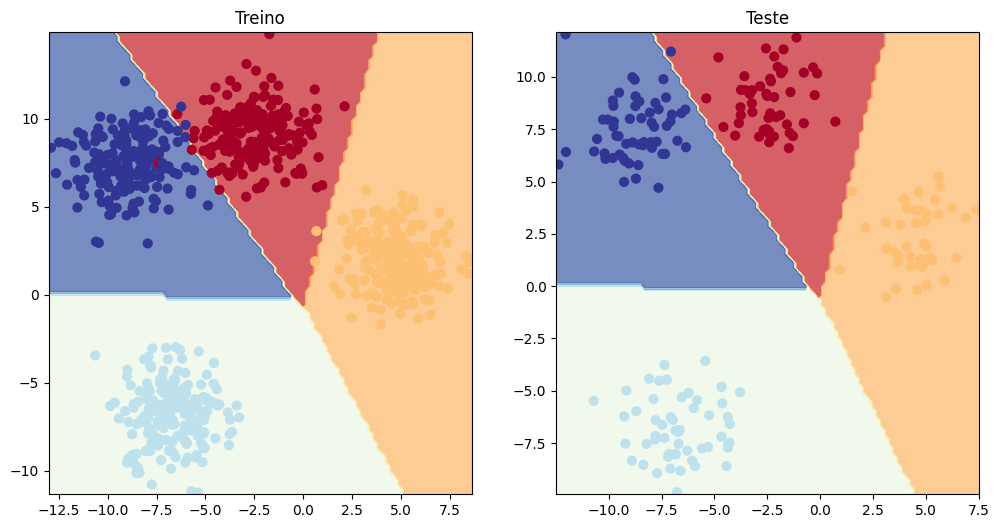

In [87]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Treino")
plot_decision_boundary(model_1_4, X_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Teste")
plot_decision_boundary(model_1_4, X_blob_test, y_blob_test)


## 9. Mais algumas métricas de classificação... (para avaliar nosso modelo  de classificação)

* Acurácia - Com 100 amostras, quantas nosso modelo acerta?
* Precisão
* Recall
* F1-score
* Matriz de confusão
* Classificaton report (relatório de classificação)


In [88]:
from torchmetrics import Accuracy

# Configurar a métrica
torchmetric_accuracy = Accuracy(task = "multiclass", num_classes = 4).to(device)
# Calcular a acurácia
torchmetric_accuracy(y_preds, y_blob_test)

tensor(0.9950)

## Exercicios e Extra-curriculares

### Modelo de classificação binária

In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


X_moon , y_moon = make_moons(n_samples = 1000, random_state= 42, noise = 0.2)
X_moon_train, X_moon_test, y_moon_train, y_moon_test = train_test_split(X_moon,
                                                                        y_moon,
                                                                        test_size = 0.2,
                                                                        random_state = 42)
len(X_moon_train), len(y_moon_train) , len(X_moon_test), len(y_moon_test)




(800, 800, 200, 200)

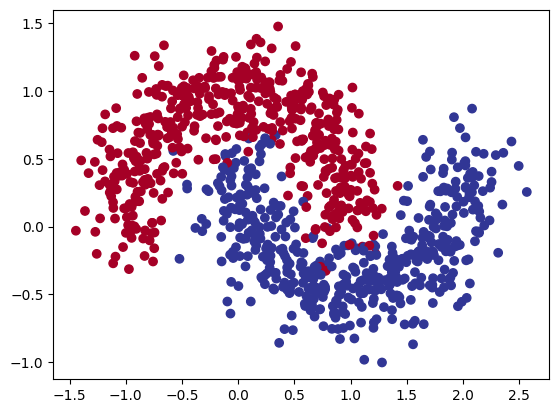

In [3]:
# visualize, visualize, visualize
import matplotlib.pyplot as plt
plt.scatter(x = X_moon[:,0],
            y = X_moon[:,1],
            c = y_moon,
            cmap = plt.cm.RdYlBu)

In [4]:
class ModelMoon(nn.Module):
    def __init__(self):
        super().__init__()
        self.rede = nn.Sequential(nn.Linear(in_features = 2, out_features = 15),
                                  nn.ReLU(),
                                  nn.Linear(in_features = 15, out_features = 15),
                                  nn.ReLU(),
                                  nn.Linear(in_features = 15, out_features = 1))
    def forward(self, x):
        return self.rede(x)

model_ex = ModelMoon().to(device)

In [5]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = model_ex.parameters(),
                             lr = 0.01)
from torchmetrics import Accuracy
torchmetric_accuracy = Accuracy(task = "binary").to(device)

In [6]:
X_moon_train = torch.from_numpy(X_moon_train).type(torch.float)
X_moon_test = torch.from_numpy(X_moon_test).type(torch.float)
y_moon_train = torch.from_numpy(y_moon_train).type(torch.float)
y_moon_test =  torch.from_numpy(y_moon_test).type(torch.float)

In [7]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000
X_moon_train, y_moon_train = X_moon_train.to(device), y_moon_train.to(device)
X_moon_test, y_moon_test = X_moon_test.to(device), y_moon_test.to(device)

for epoch in range(epochs):

    model_ex.train()
    y_logits = model_ex(X_moon_train)
    y_logits = model_ex(X_moon_train).squeeze()
    loss = loss_fn(y_logits, y_moon_train)

    y_preds = torch.round(torch.sigmoid(y_logits))
    acc = torchmetric_accuracy(y_preds , y_moon_train) * 100

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_ex.eval()
    with torch.inference_mode():

        y_test_logits = model_ex(X_moon_test).squeeze()
        y_test_preds = torch.round(torch.sigmoid(y_test_logits))
        
        test_loss = loss_fn(y_test_logits, y_moon_test)
        test_acc = torchmetric_accuracy(y_test_preds, y_moon_test) * 100
    
    if epoch % 10 == 0:
        print(f"Época: {epoch} | loss: {loss:.4f} | acc: {acc:.2f}% | loss teste: {test_loss:.4f} | acc teste: {test_acc:.2f}%")


Época: 0 | loss: 0.7015 | acc: 50.00% | loss teste: 0.6895 | acc teste: 50.00%
Época: 10 | loss: 0.5814 | acc: 84.00% | loss teste: 0.5721 | acc teste: 82.00%
Época: 20 | loss: 0.3889 | acc: 85.12% | loss teste: 0.3810 | acc teste: 83.50%
Época: 30 | loss: 0.2862 | acc: 87.00% | loss teste: 0.2784 | acc teste: 87.00%
Época: 40 | loss: 0.2442 | acc: 88.75% | loss teste: 0.2302 | acc teste: 89.00%
Época: 50 | loss: 0.2086 | acc: 91.50% | loss teste: 0.1949 | acc teste: 91.50%
Época: 60 | loss: 0.1669 | acc: 94.00% | loss teste: 0.1476 | acc teste: 94.00%
Época: 70 | loss: 0.1277 | acc: 96.12% | loss teste: 0.1075 | acc teste: 97.50%
Época: 80 | loss: 0.1007 | acc: 96.88% | loss teste: 0.0768 | acc teste: 98.00%
Época: 90 | loss: 0.0859 | acc: 97.25% | loss teste: 0.0622 | acc teste: 97.50%
Época: 100 | loss: 0.0772 | acc: 97.38% | loss teste: 0.0530 | acc teste: 98.50%
Época: 110 | loss: 0.0726 | acc: 97.25% | loss teste: 0.0487 | acc teste: 98.50%
Época: 120 | loss: 0.0689 | acc: 97.50%

In [146]:
model_ex.eval()
with torch.inference_mode():
    y_logits = model_ex(X_moon_test)
    y_preds = torch.round(torch.sigmoid(y_logits)) 

y_preds[:10], y_moon_test[:10]    

(tensor([[1.],
         [0.],
         [1.],
         [0.],
         [1.],
         [1.],
         [0.],
         [0.],
         [1.],
         [0.]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

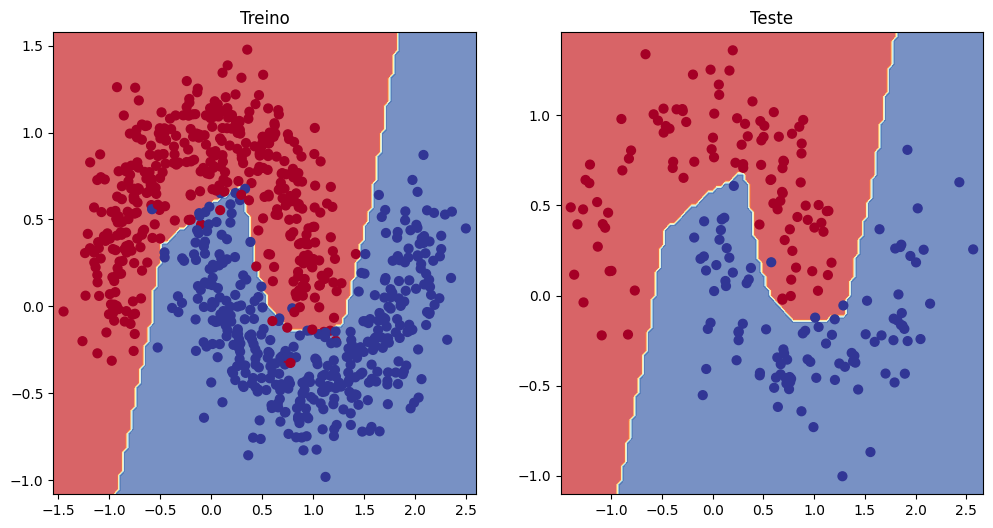

In [10]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Treino")
plot_decision_boundary(model_ex, X = X_moon_train, y = y_moon_train)
plt.subplot(1,2,2)
plt.title("Teste")
plot_decision_boundary(model = model_ex, X = X_moon_test, y = y_moon_test)

In [147]:
def Tanh(x):
    return ((torch.exp(x) - torch.exp(-x))/ ((torch.exp(x)) + torch.exp(-x))) 


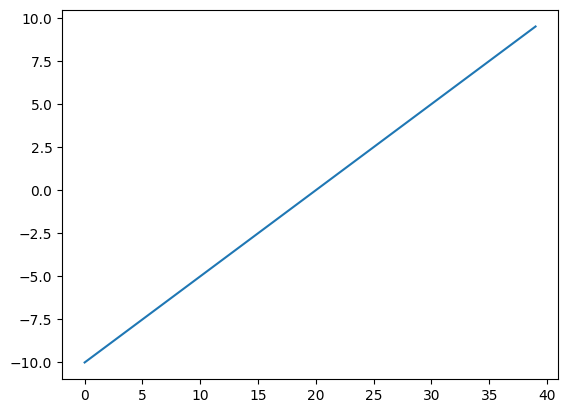

In [151]:
B = torch.arange(-10, 10, 0.5)
plt.plot(B)

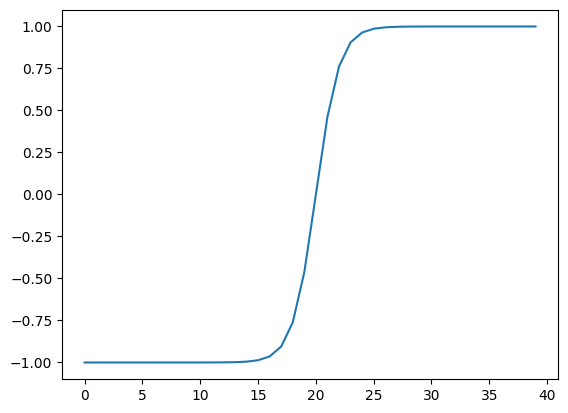

In [152]:
plt.plot(Tanh(B))

### Modelo de classificação multiclasses

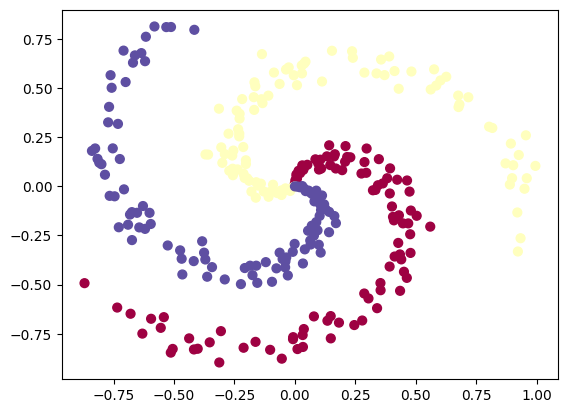

In [15]:
# Code for creating a spiral dataset from CS231n
import numpy as np
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [16]:
X = torch.from_numpy(X)
y = torch.from_numpy(y)

X = X.type(torch.float)
y = y.type(torch.LongTensor)

In [17]:
X[:3], y[:3]

(tensor([[-0.0000,  0.0000],
         [-0.0015,  0.0100],
         [ 0.0057,  0.0194]]),
 tensor([0, 0, 0]))

In [18]:
class ModelMulti(nn.Module):
    def __init__(self):
        super().__init__()
        self.rede = nn.Sequential(nn.Linear(in_features = 2, out_features = 15),
                                  nn.ReLU(),
                                  nn.Linear(in_features = 15, out_features = 15),
                                  nn.ReLU(),
                                  nn.Linear(in_features = 15, out_features = 3))
    def forward(self, x):
        return self.rede(x)

model_ex2 = ModelMulti().to(device)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 42,
                                                    test_size = 0.2)

len(X_train), len(X_test), len(y_train), len(y_test)

(240, 60, 240, 60)

In [20]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_ex2.parameters(),
                             lr = 0.005)
acc_metric = Accuracy(task = "multiclass", num_classes = 3).to(device)

In [21]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs = 1000
X_train, X_test, y_train, y_test = X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device)

for epoch in range(epochs):
    model_ex2.train()
    y_logits = model_ex2(X_train)
    y_pred = torch.softmax(y_logits, dim = 1).argmax(dim = 1)
    loss = loss_fn(y_logits, y_train)
    acc = acc_metric(y_pred, y_train) * 100
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_ex2.eval()
    with torch.inference_mode():
        y_test_logits = model_ex2(X_test)
        y_test_pred = torch.softmax(y_test_logits, dim = 1).argmax(dim = 1)
        test_loss = loss_fn(y_test_logits, y_test_pred)
        test_acc = acc_metric(y_test_pred, y_test) * 100
    if epoch % 100 == 0:
        print(f"Època: {epoch} | loss: {loss:.4f} | acc: {acc:.2f}% | Loss teste: {test_loss:.4f} | Teste acc: {test_acc:.2f}%")



Època: 0 | loss: 1.0910 | acc: 32.50% | Loss teste: 0.9667 | Teste acc: 36.67%
Època: 100 | loss: 0.4313 | acc: 79.58% | Loss teste: 0.4271 | Teste acc: 68.33%
Època: 200 | loss: 0.1165 | acc: 97.50% | Loss teste: 0.1008 | Teste acc: 100.00%
Època: 300 | loss: 0.0622 | acc: 99.17% | Loss teste: 0.0410 | Teste acc: 98.33%
Època: 400 | loss: 0.0450 | acc: 99.17% | Loss teste: 0.0267 | Teste acc: 98.33%
Època: 500 | loss: 0.0359 | acc: 99.17% | Loss teste: 0.0237 | Teste acc: 100.00%
Època: 600 | loss: 0.0304 | acc: 99.17% | Loss teste: 0.0148 | Teste acc: 100.00%
Època: 700 | loss: 0.0268 | acc: 99.17% | Loss teste: 0.0127 | Teste acc: 100.00%
Època: 800 | loss: 0.0241 | acc: 99.17% | Loss teste: 0.0161 | Teste acc: 98.33%
Època: 900 | loss: 0.0222 | acc: 99.17% | Loss teste: 0.0078 | Teste acc: 98.33%


In [22]:
model_ex2.eval()
with torch.inference_mode():
    y_logits = model_ex2(X_test)

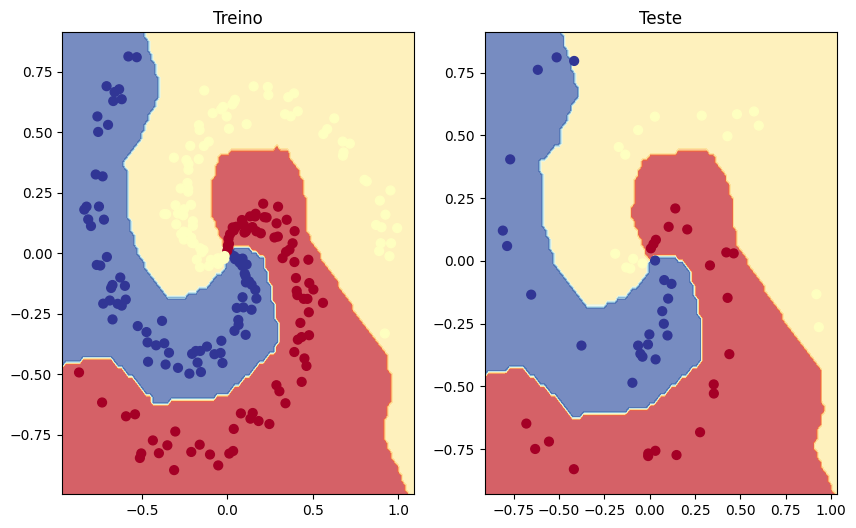

In [23]:
plt.figure(figsize = (10,6))
plt.subplot(1,2,1)
plt.title("Treino")
plot_decision_boundary(model = model_ex2, X = X_train, y = y_train)
plt.subplot(1,2,2)
plt.title("Teste")
plot_decision_boundary(model = model_ex2, X = X_test, y = y_test)

In [24]:
next(model_ex2.parameters())

Parameter containing:
tensor([[-0.1549,  0.1427],
        [-1.0987,  1.6854],
        [ 2.4313, -1.8137],
        [ 1.5563,  0.1892],
        [ 2.6827,  2.3083],
        [ 1.3363,  2.0948],
        [ 2.6255,  1.3876],
        [-1.1937,  1.9715],
        [-0.6405, -0.8711],
        [-1.1709,  2.2634],
        [-0.8799, -0.6800],
        [-1.9032, -2.5294],
        [ 1.9730, -1.6275],
        [ 2.6465, -1.8199],
        [ 2.1025,  2.0388]], requires_grad=True)

# 03. Visão computacional com PyTorch 

## 0. Bibliotecas de visão computacional em PyTorch

* `torchvision` - Biblioteca de domínio base para visão computacional com PyTorch
* `torchvision.datasets` - Obtenha conjuntos de dados e funções de carregamentos de dados para visão computacional
* `torchvision.models` - Obtenha modelos de visão computacional pré-treinados para voce aproveitar para o seu problema
* `torchvision.transforms` - Funções para manipulação dos seus dados de visão computacional(imagens), para que fiquem adequadas para serem usadas em um modelo de ML
* `torch.utils.data.Dataset`- Classe base  de conjuntos de dados para PyTorch
*  `torch.utils.data.DataLoader` - Cia um iterável Python em um dataset

In [2]:
# import PyTorch
import torch
from torch import nn

# import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# import matplotlib para visualização
import matplotlib.pyplot as plt

# verificar as versões
print(torch.__version__)
print(torchvision.__version__)


2.12.0+cu130
0.27.0+cu130


## 1. Obtendo um conjunto de dados

O conjunto de dados do torchvision.datasets que será ultilizado é: FashionMNIST 

In [3]:
# Configurar dados de treinamento
train_data = datasets.FashionMNIST(
    root = "data", # Onde fazer o download dos dados
    train = True, # Queremos o conjunto de dados de treinamento?
    download = True, # Queremos fazer o download (sim/não)?
    transform = torchvision.transforms.ToTensor(), # Como queremos transformar os dados?
    target_transform = None # Como queremos transformar os rótulos/alvos?
)

test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor(),
    target_transform = None
)

100.0%
100.0%
100.0%
100.0%


In [4]:
len(train_data), len(test_data)

(60000, 10000)

In [7]:
# Ver o primeiro exemplo de treinamento
image, label = train_data[0]

image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [8]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [9]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [10]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

### 1.1 Checando o formato de entrada e de saída dos dados

In [14]:
# Checar o formato da nossa imagem
print(f"Formato da imagem: {image.shape} -> [canais de cores, altura, largura]") 
print(f" Rótulo da imagem: {class_names[label]}")

Formato da imagem: torch.Size([1, 28, 28]) -> [canais de cores, altura, largura]
 Rótulo da imagem: Ankle boot


### 1.2 Visualizando nossos dados

Formato da imagem: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

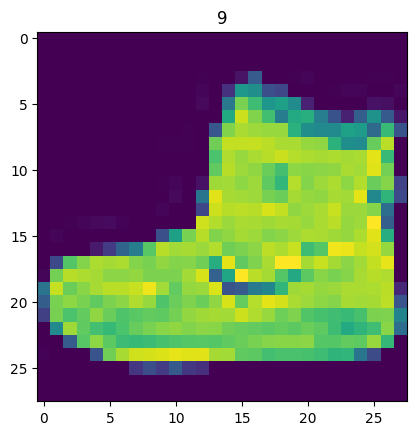

In [18]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Formato da imagem: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

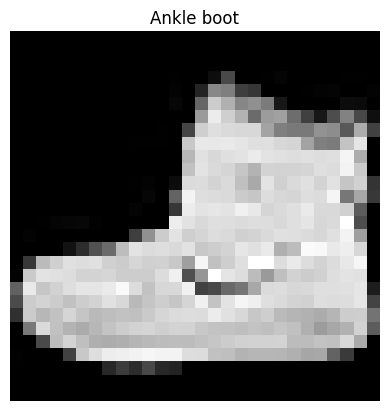

In [22]:
plt.imshow(image.squeeze(), cmap = "gray")
plt.title(class_names[label])
plt.axis(False)

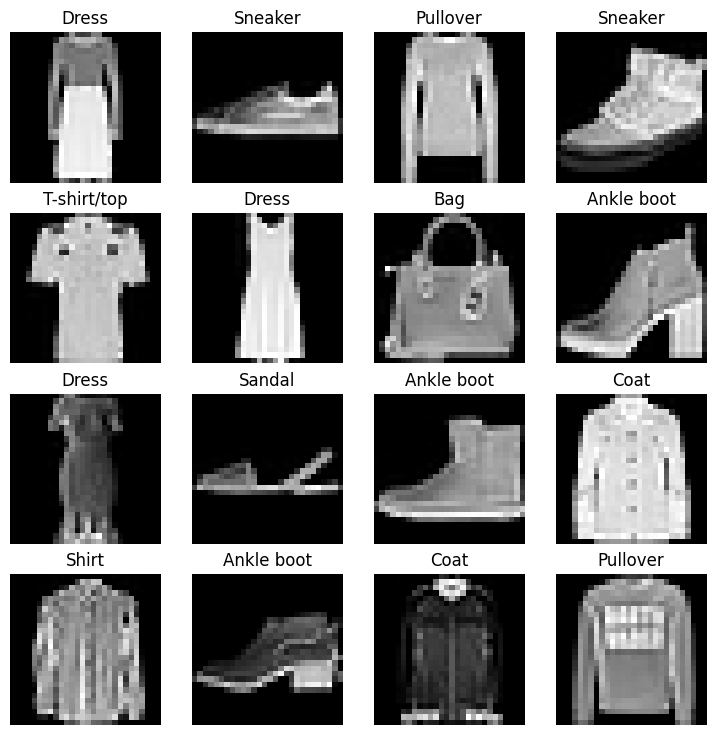

In [31]:
# Plotar mais imagens
#torch.manual_seed(42)
fig = plt.figure(figsize = (9,9))
rows, cols = 4,4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size = [1]).item()
    image, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(image.squeeze(), cmap = "gray")
    plt.title(class_names[label])
    plt.axis(False)

Voce acha que esses itens de vestuario (imagens) podem ser modelados com linhas lineares? Ou voce acha que precisaremos de não linearidade?


In [33]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

## 2. Preparar o DataLoader(carregamento de dados)

Nossos dados estão na forma de conjunto de dados PyTorch.

DataLoader transforma nosso conjunto de dados em um iterável python.

Mais especificamente, queremos transformar nossos dados em lotes ou minilotes(batches ou mini-batches).

Por que fariamos isso?

1. É mais eficiente do ponto de vista computacional , no hardware talvez não seja possível procurar na memória 60000 imagens de uma vez só. Então nós quebramos isso em 32 imagens por vez (lote de tamanho 32).
2. Isso dá à nossa rede neural mais chances de atualizar seus gradientes por época


In [35]:
from torch.utils.data import DataLoader

# Configure o hiperparametro tamanho do lote (batch size)
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              shuffle = True)

test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             shuffle = False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7a64c16a8f50>,
 <torch.utils.data.dataloader.DataLoader at 0x7a64c17a07d0>)

In [37]:
# Vamos checar o que criamos
print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Comprimento do train_dataloader: {len(train_dataloader)} lotes de {BATCH_SIZE}...")
print(f"Comprimento do test_dataloader: {len(test_dataloader)} lotes de {BATCH_SIZE}...")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x7a64c16a8f50>, <torch.utils.data.dataloader.DataLoader object at 0x7a64c17a07d0>)
Comprimento do train_dataloader: 1875 lotes de 32...
Comprimento do test_dataloader: 313 lotes de 32...


In [38]:
# Verificar o que está dentro do train_dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Tamanho da imagem: torch.Size([1, 28, 28])
Rótulo: 5, tamanho do rótulo: torch.Size([])


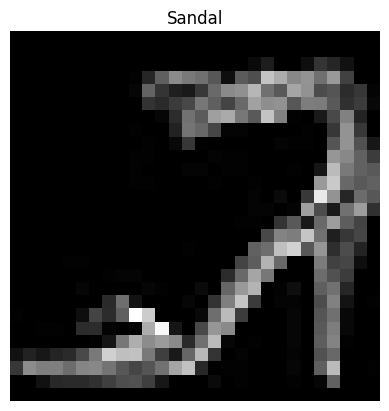

In [57]:
# Mostrar um exemplo
#torch.manual_seed(42)
random_idx = torch.randint(0,len(train_features_batch), size = [1]).item()
img,label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap = "gray")
plt.title(class_names[label])
plt.axis(False)
print(f"Tamanho da imagem: {img.shape}")
print(f"Rótulo: {label}, tamanho do rótulo: {label.shape}")

## 3. Modelo 0: Construir um modelo linha de base 

Ao começar a criar uma série de experimentos de modelagem de aprendizado de máquina, a melhor prática é começar com um modelo de linha de base.

Um modelo de linha de base é um modelo simples, voce tentará melhorá-lo com o modelo/experimento subsequente.

Em outras palavras: Comece de forma simples e adicione complexidade quando necessário.

In [ ]:
# Criar a flatten layer( camada achatada)
flatten_model = nn.Flatten()

# Obter uma única amostra
x = train_features_batch[0]

# Achatar a amostra
output = flatten_model(x) # executa a inferência

# Imprimir o que aconteceu
print(f"Formato antes do achatamento: {x.shape} -> [canais de cores, altura, largura]")
print(f"Formato depois do achatamento: {output.shape} -> [canais de cores, altura*largura]")

Formato antes do achatamento: torch.Size([1, 28, 28])
Formato depois do achatamento: torch.Size([1, 784])


In [62]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_shape,
                      out_features = hidden_units),
            nn.Linear(in_features = hidden_units,
                      out_features = output_shape)
        )
    def forward(self,x):
        return self.layer_stack(x)



In [63]:
torch.manual_seed(42)

# Configurar o modelo com parametros de entrada
model_0 = FashionMNISTModelV0(
    input_shape = 784, # isso é 28 * 28
    hidden_units = 10, # quantas unidades na camada oculta?
    output_shape = len(class_names) # um para cada classe
    ).to("cpu")
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [64]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)